In [1]:
import jax.numpy as jnp
import jax.tree_util as jtu
from jax import nn, vmap, lax, jit
from jax import random as jr
import numpy as np

from pymdp.envs import GridWorldEnv
from pymdp.jax.task import PyMDPEnv
from pymdp.jax.agent import Agent as AIFAgent

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Observations
START = 0
CC = 1
CD = 2
DC = 3
DD = 4

# Actions
C = 0
D = 1

# States
START = 0
CC_ALLC = 1
CD_ALLC = 2
DC_ALLC = 3
DD_ALLC = 4
CC_ALLD = 5
CD_ALLD = 6
DC_ALLD = 7
DD_ALLD = 8
CC_TFT = 9
CD_TFT = 10
DC_TFT = 11
DD_TFT = 12


ALL_STATES = [START, CC_ALLC, CD_ALLC, DC_ALLC, DD_ALLC, CC_ALLD, CD_ALLD, DC_ALLD, DD_ALLD, CC_TFT, CD_TFT, DC_TFT, DD_TFT]
ALL_STATES_LABELS = ["START", "CC_ALLC", "CD_ALLC", "DC_ALLC", "DD_ALLC", "CC_ALLD", "CD_ALLD", "DC_ALLD", "DD_ALLD", "CC_TFT", "CD_TFT", "DC_TFT", "DD_TFT"]
ALL_OBS = [START, CC, CD, DC, DD]
ALL_OBS_LABELS = ["START", "CC", "CD", "DC", "DD"]
ALL_ACTIONS = [C, D]
ALL_ACTIONS_LABELS = ["C", "D"]

In [3]:
n_batches = 1
n_turns = 100

num_states = len(ALL_STATES)
num_obs = len(ALL_OBS)
num_actions = len(ALL_ACTIONS)

In [4]:
def plot_A_1(A_1):
    plt.figure(figsize=(20, 5))
    sns.heatmap(A_1, annot=True, cmap='viridis', cbar=False)
    # label axes 
    ticks = [i + 0.5 for i in range(num_states)]
    plt.xticks(ticks=ticks, labels=ALL_STATES_LABELS)
    ticks = [i + 0.5 for i in range(num_obs)]
    plt.yticks(ticks=ticks, labels=ALL_OBS_LABELS)
    
    
    plt.title('Transition Matrix A_1')
    plt.xlabel('Observation')
    plt.ylabel('State')
    plt.show()



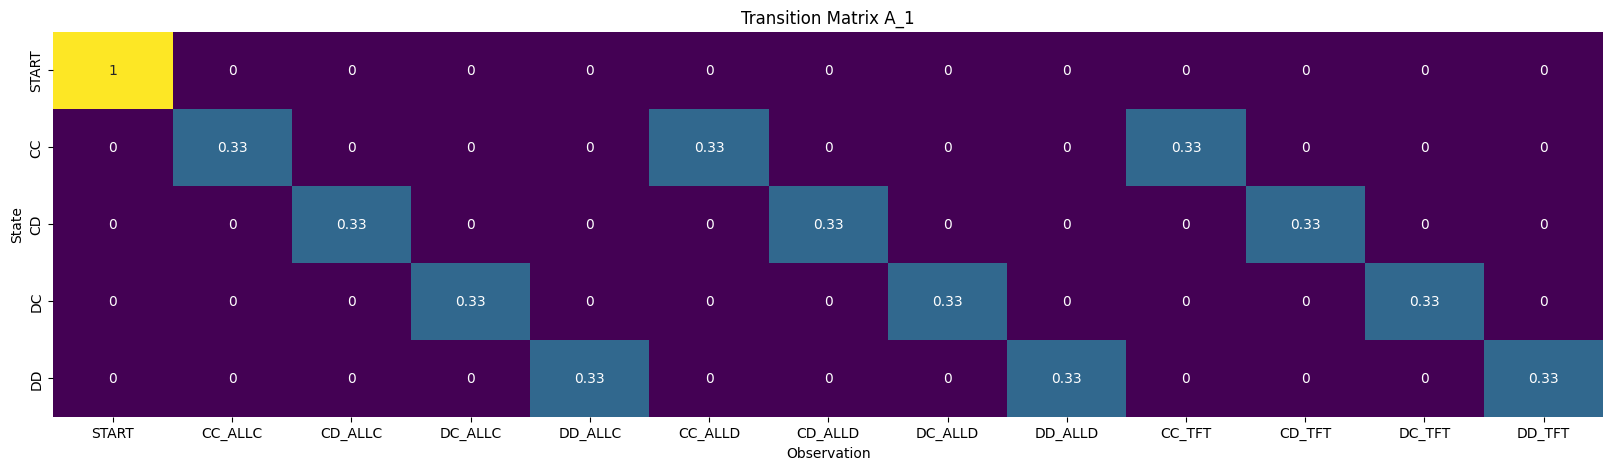

In [5]:
# Define A matrix
A_1 = np.zeros((num_obs, num_states))
A_1[START, START] = 1
A_1[CC, [CC_ALLC, CC_ALLD, CC_TFT]] = 0.333
A_1[CD, [CD_ALLC, CD_ALLD, CD_TFT]] = 0.333
A_1[DC, [DC_ALLC, DC_ALLD, DC_TFT]] = 0.333
A_1[DD, [DD_ALLC, DD_ALLD, DD_TFT]] = 0.333

plot_A_1(A_1)

In [6]:
def plot_B_1(B_1):
    # B_1 Shape (next_state, current_state, action)
    assert B_1.shape == (num_states, num_states, num_actions), f"B_1 shape is {B_1.shape}, expected (num_states, num_states, num_actions)"
    plt.figure(figsize=(20, 10))
    for action in range(num_actions):
        plt.subplot(1, num_actions, action + 1)
        sns.heatmap(B_1[:, :, action], annot=True, cmap='viridis', cbar=False)
        # offset labels on ticks by 0.5
        ticks = [i + 0.5 for i in range(num_states)]
        plt.xticks(ticks=ticks, labels=ALL_STATES_LABELS)
        plt.yticks(ticks=ticks, labels=ALL_STATES_LABELS)
        plt.title(f'B_1 for action {ALL_ACTIONS_LABELS[action]}')
        plt.xlabel('Next State')
        plt.ylabel('Current State')
        plt.tight_layout()
    
  
    plt.show()

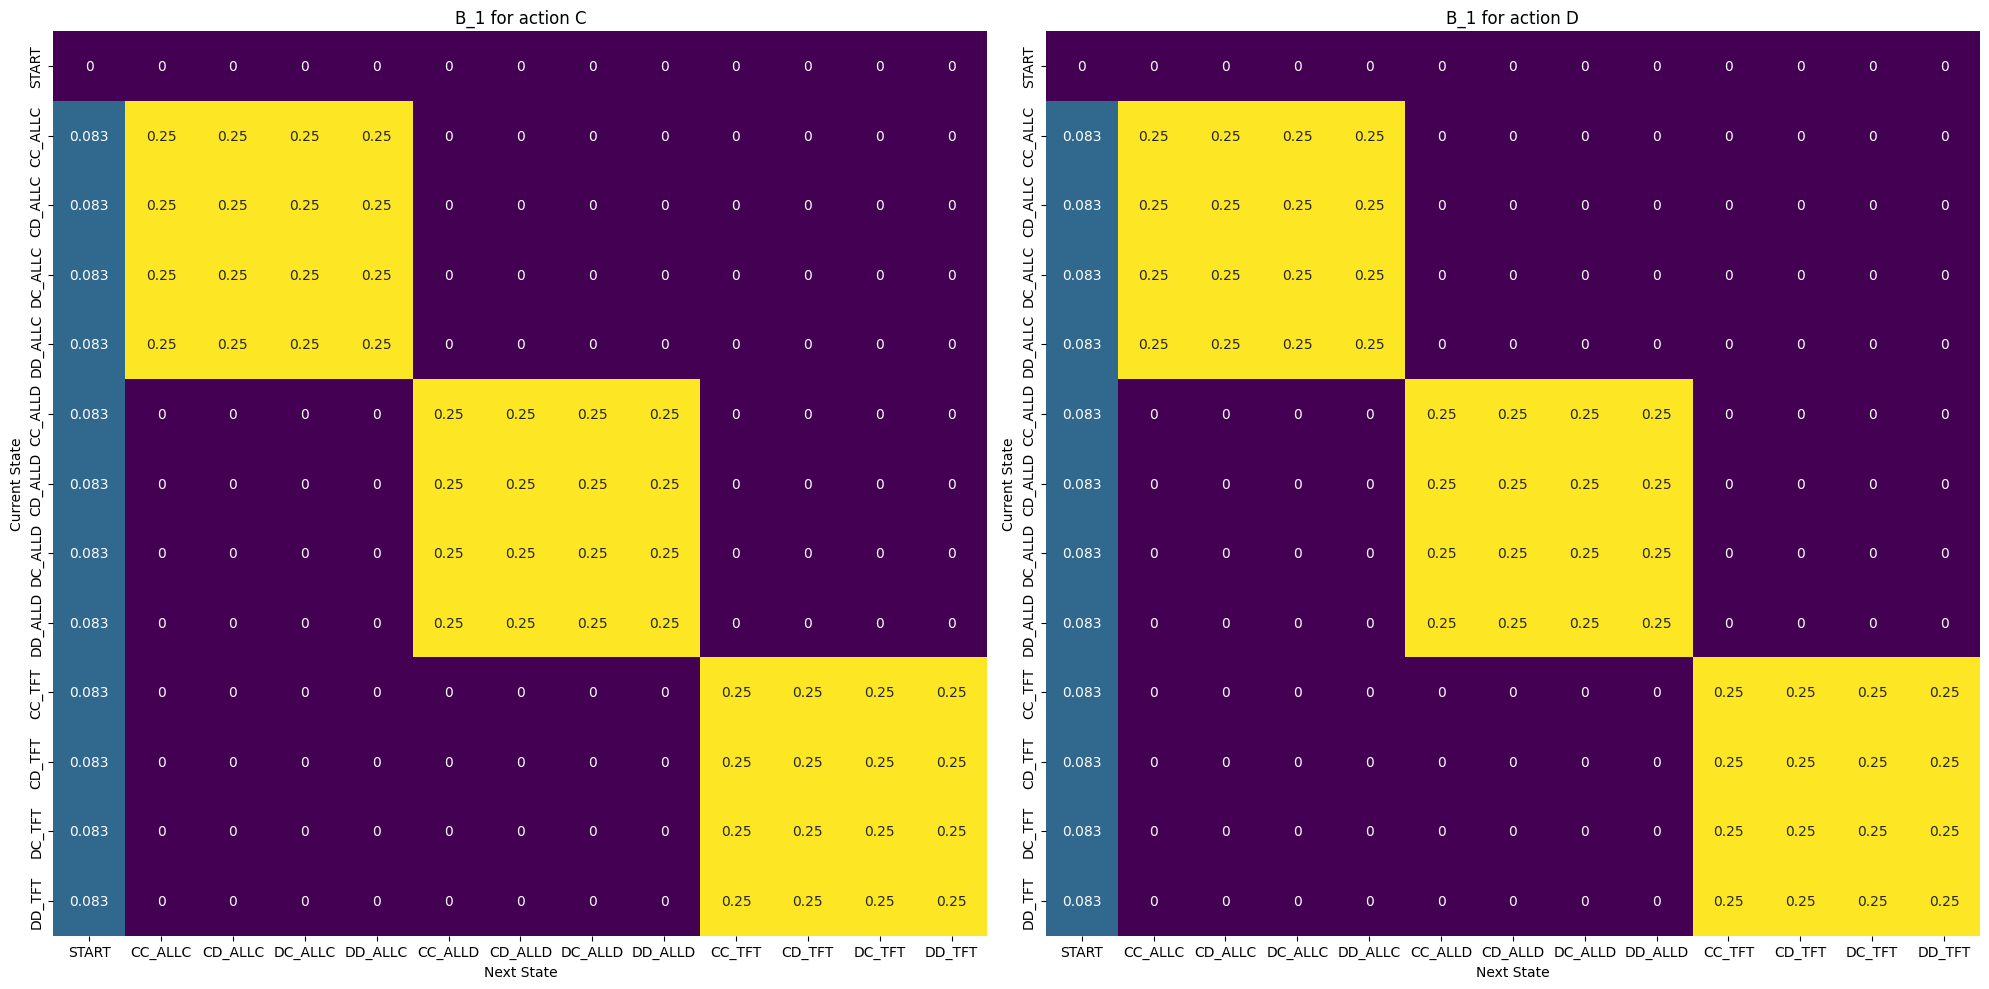

In [7]:
B_1 = np.zeros((num_states, num_states, num_actions))
ALLC_STATES = [CC_ALLC, CD_ALLC, DC_ALLC, DD_ALLC]
ALLD_STATES = [CC_ALLD, CD_ALLD, DC_ALLD, DD_ALLD]
TFT_STATES = [CC_TFT, CD_TFT, DC_TFT, DD_TFT]

B_1[ALL_STATES[1:], START, :] = 1 / (len(ALL_STATES) - 1)
# but only ALLC_STATES can go to ALLC_STATES
B_1[CC_ALLC: CC_ALLD, CC_ALLC: CC_ALLD, :] = 0.25
# but only ALLD_STATES can go to ALLD_STATES
B_1[CC_ALLD: CC_TFT, CC_ALLD: CC_TFT, :] = 0.25
# but only TFT_STATES can go to TFT_STATES
B_1[CC_TFT: , CC_TFT: , :] = 0.25







plot_B_1(B_1)

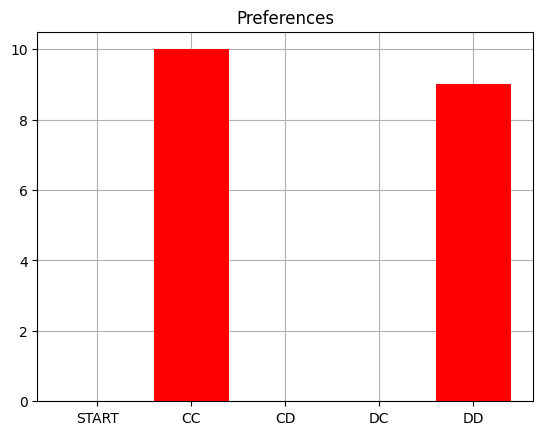

In [8]:
C_1 = np.zeros(num_obs)
C_1[CC] = 10
C_1[CD] = 0
C_1[DC] = 0
C_1[DD] = 9

def plot_C_1(C_1, title="Preferences"):
    plt.grid(zorder=0)
    plt.bar(range(C_1.shape[0]), C_1, color='r', zorder=3)
    plt.xticks(range(C_1.shape[0]), ALL_OBS_LABELS)
    plt.title(title)
    plt.show()

plot_C_1(C_1)


In [9]:
def plot_D_1(C_1, title="Initial Beliefs"):
    plt.figure(figsize=(20, 5))
    plt.grid(zorder=0)
    plt.bar(range(C_1.shape[0]), C_1, color='r', zorder=3)
    plt.xticks(range(C_1.shape[0]), ALL_STATES_LABELS)
    plt.title(title)
    plt.show()

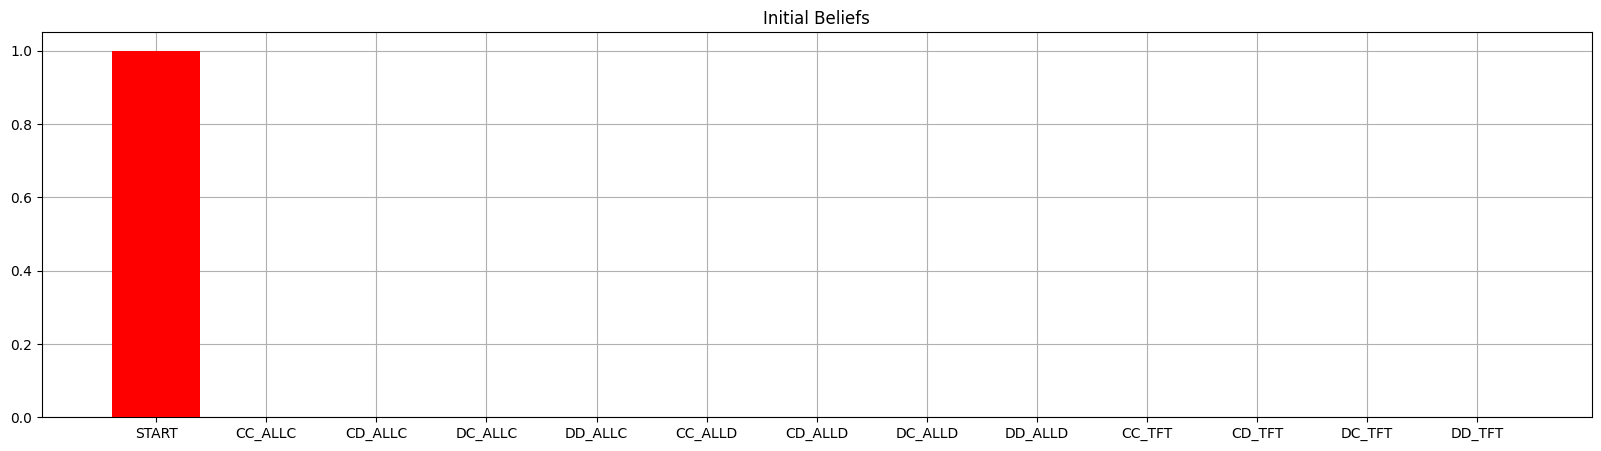

In [10]:
D_1 = np.zeros(num_states)
D_1[START] = 1

plot_D_1(D_1, "Initial Beliefs")

In [11]:
FINAL_A = [jnp.broadcast_to(A_1, (n_batches,) + (num_obs, num_states))]
FINAL_A[0].shape

(1, 5, 13)

In [12]:
FINAL_B = [jnp.broadcast_to(B_1, (n_batches,) + (num_states, num_states, num_actions))]
FINAL_B[0].shape

(1, 13, 13, 2)

In [13]:
FINAL_C = [jnp.broadcast_to(C_1, (n_batches,) + (num_obs,))]
FINAL_C[0].shape

(1, 5)

In [14]:
FINAL_D = [jnp.broadcast_to(D_1, (n_batches,) + (num_states,))]
FINAL_D[0].shape

(1, 13)

In [15]:
# pB = [jnp(FINAL_B[0]) / num_states]
import pymdp
pB = pymdp.utils.dirichlet_like(FINAL_B[0]) * 1000
pB = [jnp.broadcast_to(jnp.array(pB[0]), (n_batches,) + (num_states, num_states, num_actions))]
pA = [jnp.ones_like(FINAL_A[0]) / num_states]
print(pA[0].shape)
agents = []
for i in range(1):
    agents.append( 
        AIFAgent(
            FINAL_A,
            FINAL_B,
            FINAL_C,
            FINAL_D,
            E=None,
            pA=pA,
            pB=pB,
            policy_len=5,
            use_utility=False,
            use_states_info_gain=True,
            use_param_info_gain=True,
            gamma=jnp.ones(1),
            alpha=jnp.ones(1) * i ,
            onehot_obs=False,
            action_selection="stochastic",
            inference_algo="fpi",
            num_iter=16,
            learn_A=True,
            learn_B=True,
            learn_C=True,
            learn_D=False,
        )
    )

/home/kivalm/code/AIFNIPD/.venv/lib/python3.13/site-packages/pymdp/utils.py:332: UserWarning: Input array is not an object array...                    Casting the input to an object array
  warnings.warn(


(1, 5, 13)
(13,)


In [16]:
agents[0].batch_size

1

In [17]:
@jit
def titfortat(obs):
    obs = obs[0][0]
    def case_START():
        return jnp.array([[C]])
    def case_CC():
        return jnp.array([[C]])
    def case_CD():
        return jnp.array([[C]])
    def case_DC():
        return jnp.array([[D]])
    def case_DD():
        return jnp.array([[D]])
    return lax.switch(obs, [case_START, case_CC, case_CD, case_DC, case_DD])


titfortat([jnp.array([[DC]])][0])

Array([[1]], dtype=int32)

In [18]:
@jit
def alwaysdefect(obs):
    return jnp.array([[D]])

alwaysdefect([jnp.array([[DC]])][0])

Array([[1]], dtype=int32)

In [19]:
@jit
def alwayscooperate(obs):
    return jnp.array([[C]])

alwayscooperate([jnp.array([[DC]])][0])

Array([[0]], dtype=int32)

In [20]:
def action_pair_to_obs(action, opponent_action):
    own_action = action[0][0]
    opponent_action = opponent_action[0][0]
    # CC -> 1 , CD -> 2, DC -> 3, DD -> 4
    # get idx from pair
    idx = 1 +(own_action * 2) + opponent_action
    return jnp.array([[idx]])

action_pair_to_obs([[C]], [[C]]), action_pair_to_obs([[C]], [[D]]), action_pair_to_obs([[D]], [[C]]), action_pair_to_obs([[D]], [[D]])

(Array([[1]], dtype=int32),
 Array([[2]], dtype=int32),
 Array([[3]], dtype=int32),
 Array([[4]], dtype=int32))

In [21]:
import jax 

def rollout(rng, agent, strategy, n_turns):
    batch_size = agent.batch_size

    def step_fn(carry, t):
        print(t)
        print(carry)
        obs_t = carry["obs"]
        rng_key = carry["rng_key"]
        empirical_prior_t = carry["empirical_prior"]

        qs = agent.infer_states(obs_t, empirical_prior_t)
        print(qs)
        qpi, _ = agent.infer_policies(qs)
        print(qpi)

        rng_key = jr.split(rng_key)
        action = agent.sample_action(qpi, rng_key=rng_key[1:])

        opponent_action = strategy(obs_t[0])
        print(action)
        print(opponent_action)

        next_obs = [action_pair_to_obs(action, opponent_action)]
        print(next_obs)

        empirical_prior_t, qs = agent.update_empirical_prior(action, qs)

        carry = {
            "obs": next_obs,
            "rng_key": rng_key[0],
            "empirical_prior": empirical_prior_t,
        }

        info = {
            "obs": obs_t,
            "qs": qs,
            "qpi": qpi,
            "action": action,
            "empirical_prior": empirical_prior_t,
        }
        return carry, info
    
    keys = jr.split(rng, batch_size)
    
    obs_t0 = [jnp.broadcast_to(jnp.array([START]), (batch_size,1))]

    carry = {
        "obs": obs_t0,
        "rng_key": keys[0],
        "empirical_prior": agent.D,
    }

    last_carry, infos = lax.scan(step_fn, carry, jnp.arange(n_turns))

    return last_carry, infos

carry, infos = rollout(jr.PRNGKey(0), agents[0], titfortat, 5)

JitTracer<int32[]>
{'empirical_prior': [JitTracer<float32[1,13]>], 'obs': [JitTracer<int32[1,1]>], 'rng_key': JitTracer<uint32[2]>}
[JitTracer<float32[1,1,13]>]
JitTracer<float32[1,32]>
JitTracer<int32[1,1]>
JitTracer<int32[1,1]>
[JitTracer<int32[1,1]>]


In [22]:

Bs = []
obs = []
pB0 = 1e4 * FINAL_B[0] + 1e-4
num_timesteps = 1000
num_blocks = 10000

key = jr.PRNGKey(0)
for block in range(num_blocks):
    for i, agent in enumerate(agents):
        key, _key = jr.split(key)

        # choose a random strategy
        options = [alwaysdefect, alwayscooperate, titfortat]
        strategy = jax.tree_util.Partial(options[np.random.randint(0, len(options))])
        
        last, info = jit(rollout, static_argnums=[3,] )(_key, agent, strategy, num_timesteps)

        beliefs = info['qs']
        print(beliefs[0].shape)
        beliefs = [jnp.reshape(beliefs[0], (n_batches, num_timesteps, num_states))]
        print(beliefs[0].shape)
        print(beliefs[0][0].shape)
        print("_"*100)
        
        actions = info['action']
        print(actions.shape)
        actions = [jnp.reshape(actions, (n_batches, num_timesteps, 1))[:, :-1, :]]
        print(actions[0].shape)
        print(actions[0][0][0][0])
        print("_"*100)

        outcomes = info['obs']
        print(outcomes[0].shape)
        outcomes = [jnp.reshape(outcomes[0], (n_batches, num_timesteps))]
        print(outcomes[0].shape)
        print(outcomes[0][0][0])
        obs.append(outcomes[0])
        print("_"*100)

        agents[i] = agent.infer_parameters(beliefs, outcomes, actions[0], lr_pA=0.5, lr_pB=0.5)
        Bs.append(agents[i].B)

JitTracer<int32[]>
{'empirical_prior': [JitTracer<float32[1,13]>], 'obs': [JitTracer<int32[1,1]>], 'rng_key': JitTracer<uint32[2]>}
[JitTracer<float32[1,1,13]>]
JitTracer<float32[1,32]>
JitTracer<int32[1,1]>
JitTracer<int32[1,1]>
[JitTracer<int32[1,1]>]
(1000, 1, 1, 13)
(1, 1000, 13)
(1000, 13)
____________________________________________________________________________________________________
(1000, 1, 1)
(1, 999, 1)
0
____________________________________________________________________________________________________
(1000, 1, 1)
(1, 1000)
0
____________________________________________________________________________________________________
(1000, 1, 1, 13)
(1, 1000, 13)
(1000, 13)
____________________________________________________________________________________________________
(1000, 1, 1)
(1, 999, 1)
0
____________________________________________________________________________________________________
(1000, 1, 1)
(1, 1000)
0
_____________________________________________________

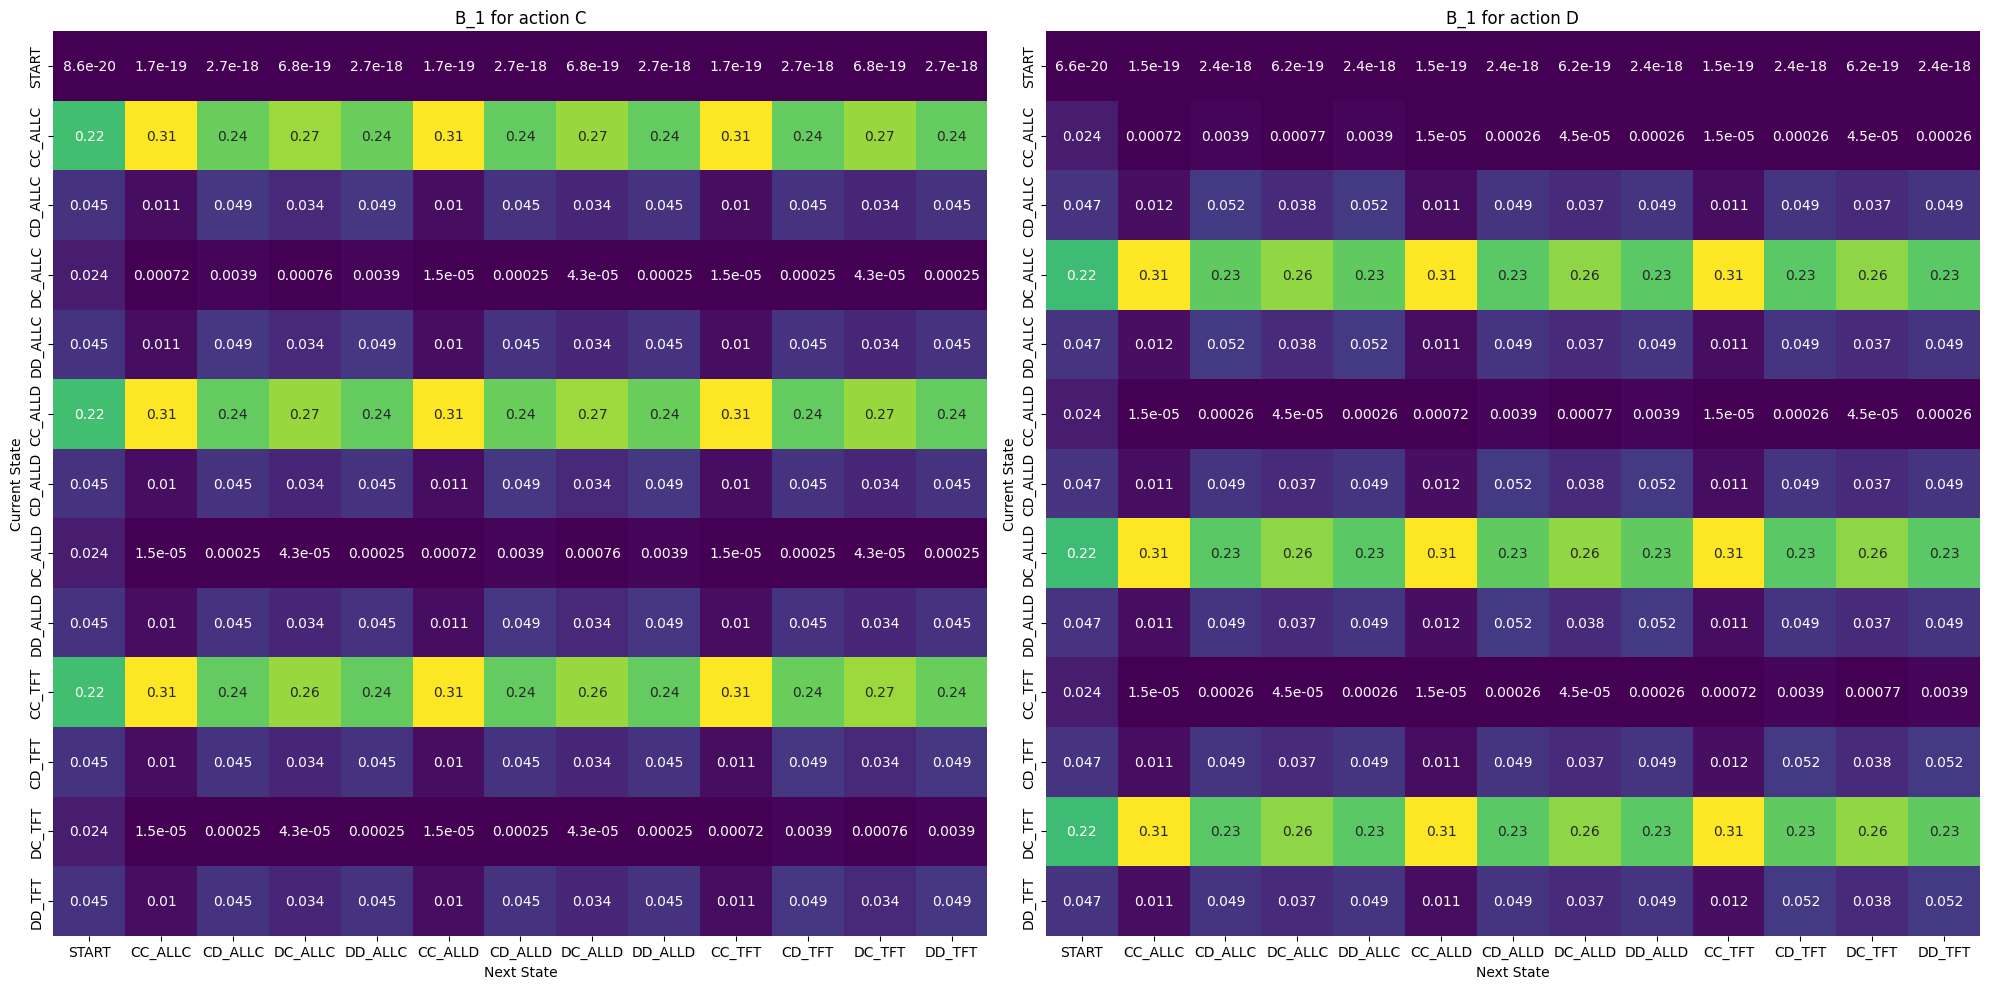

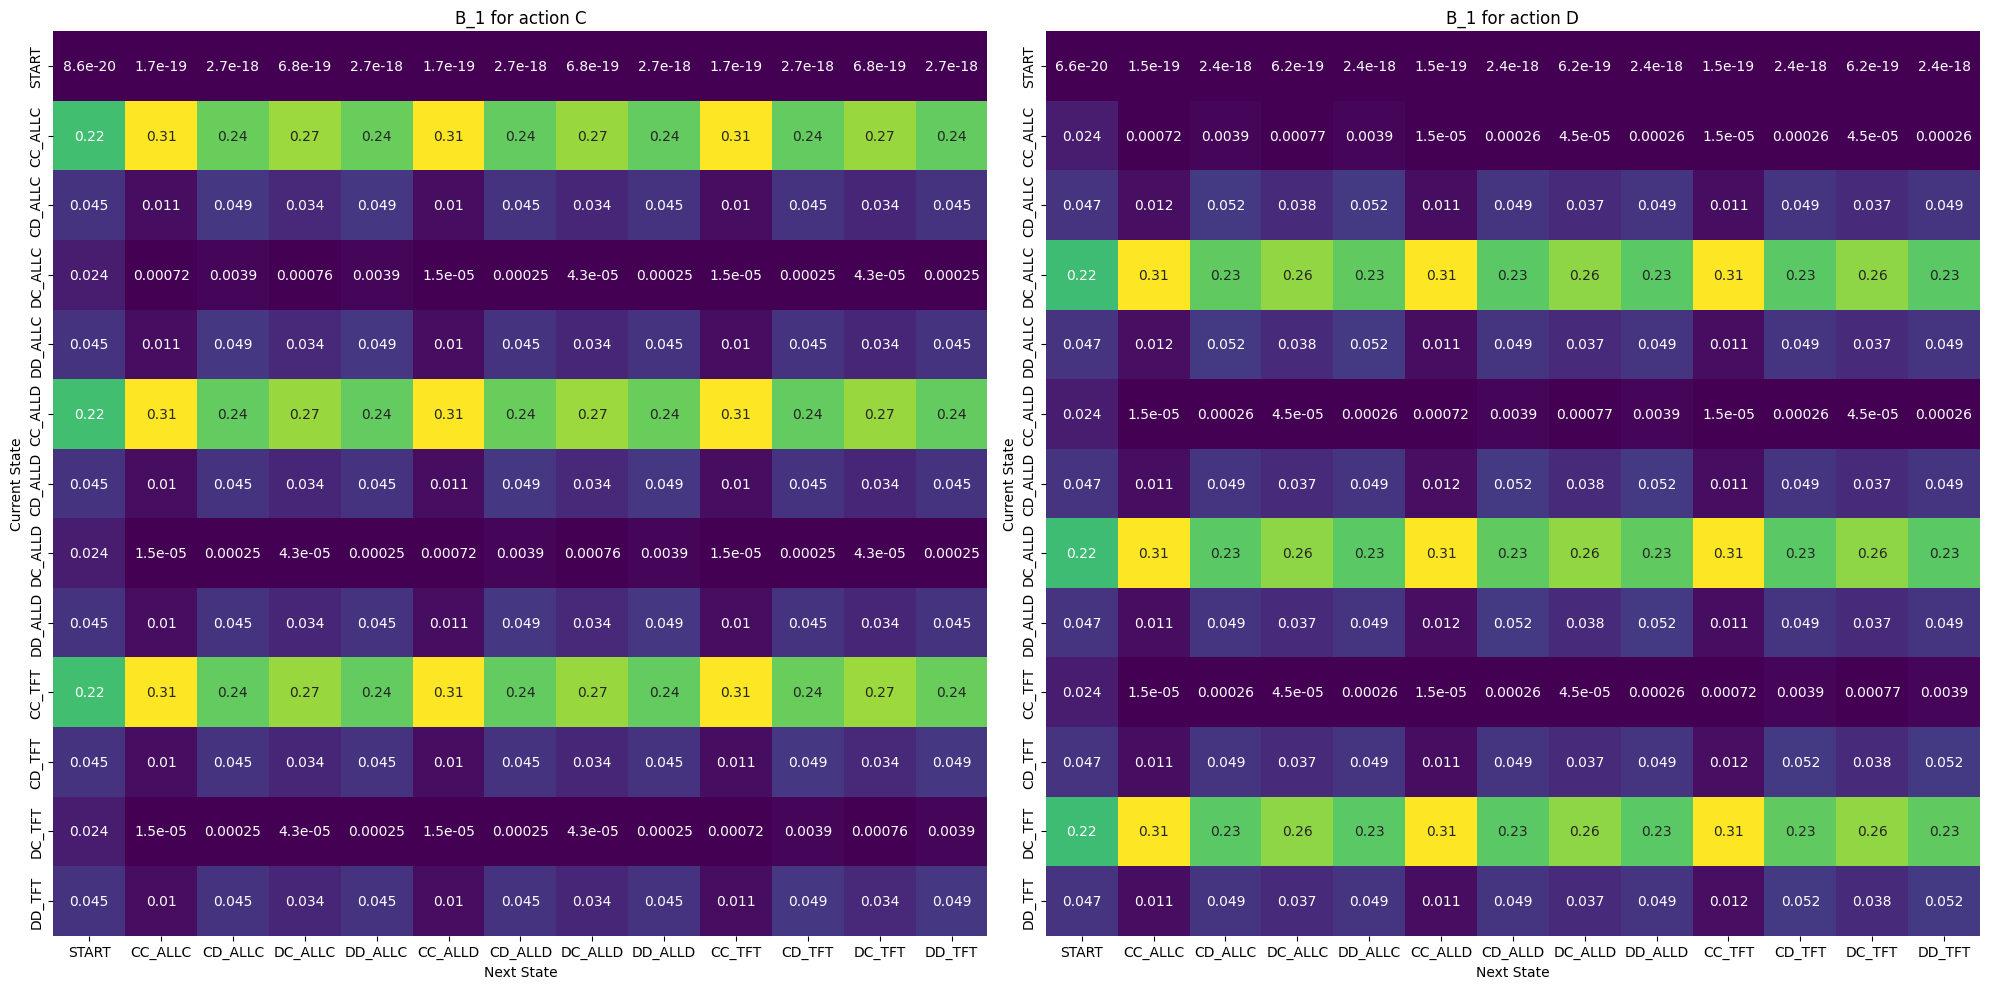

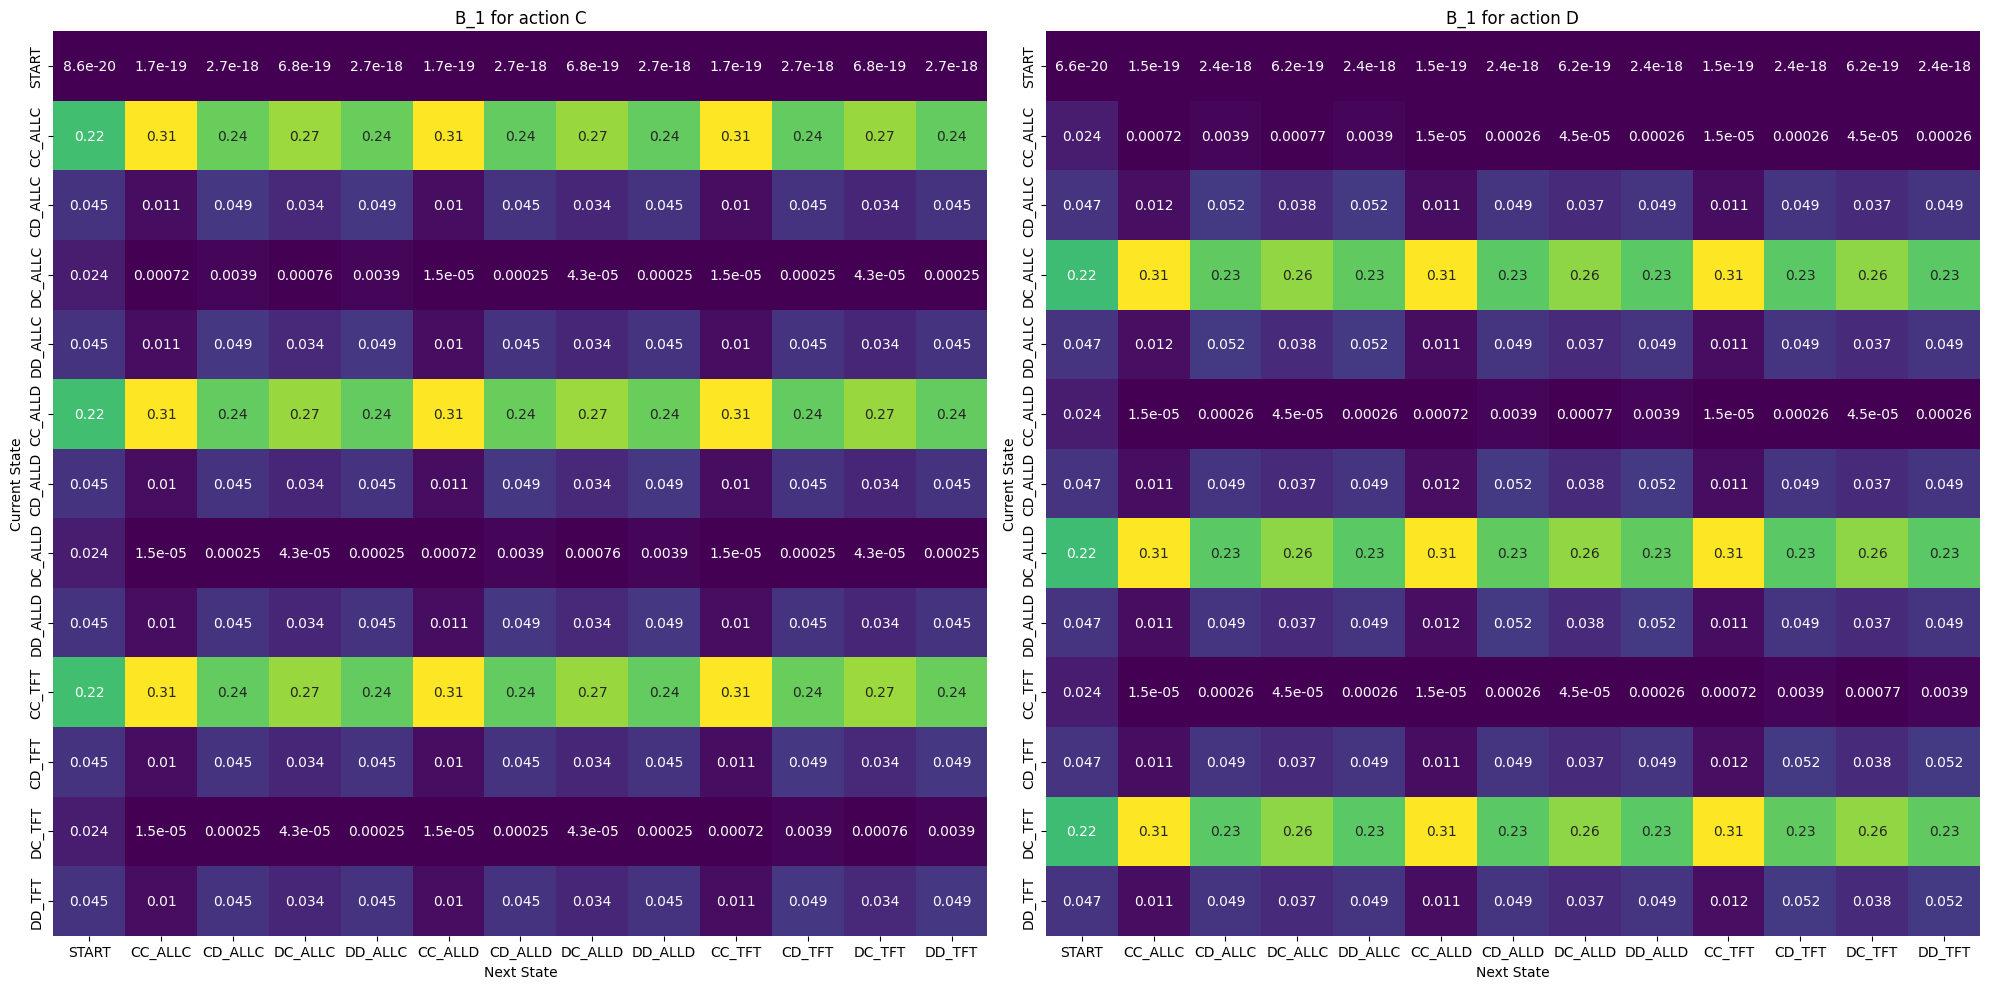

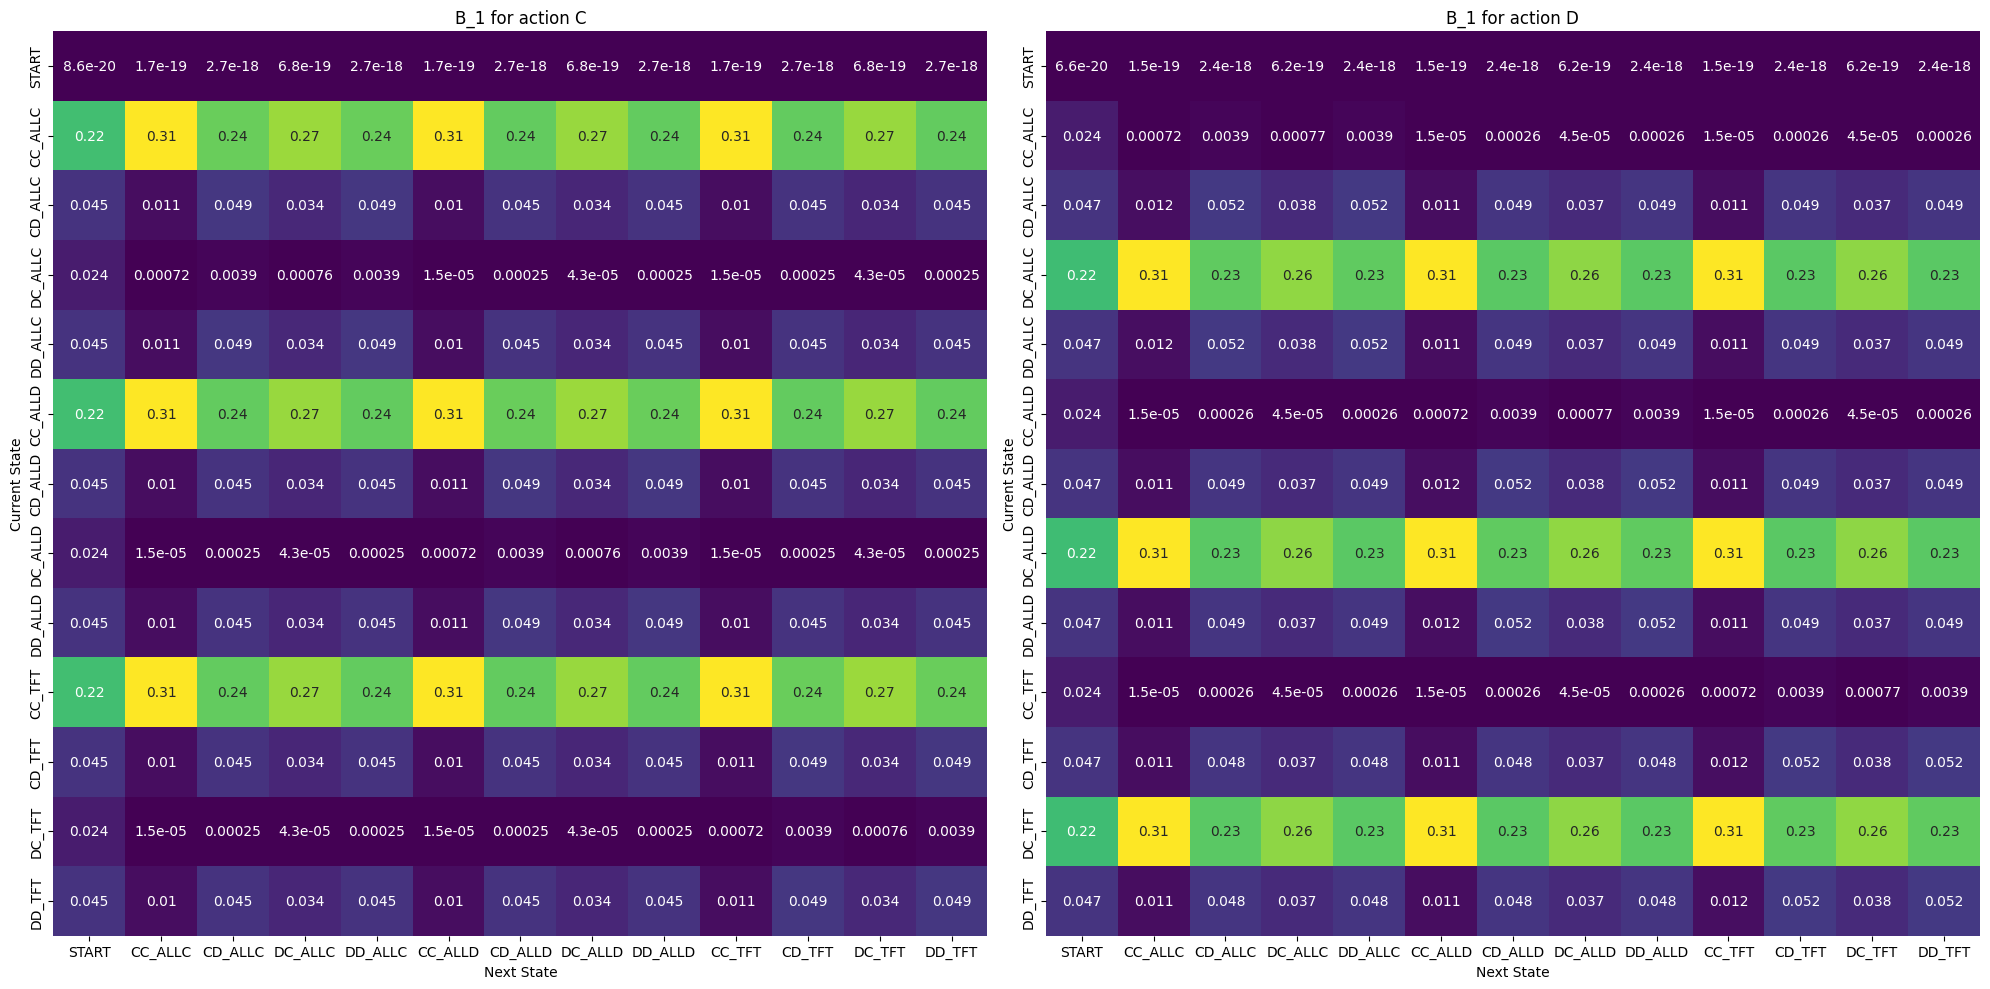

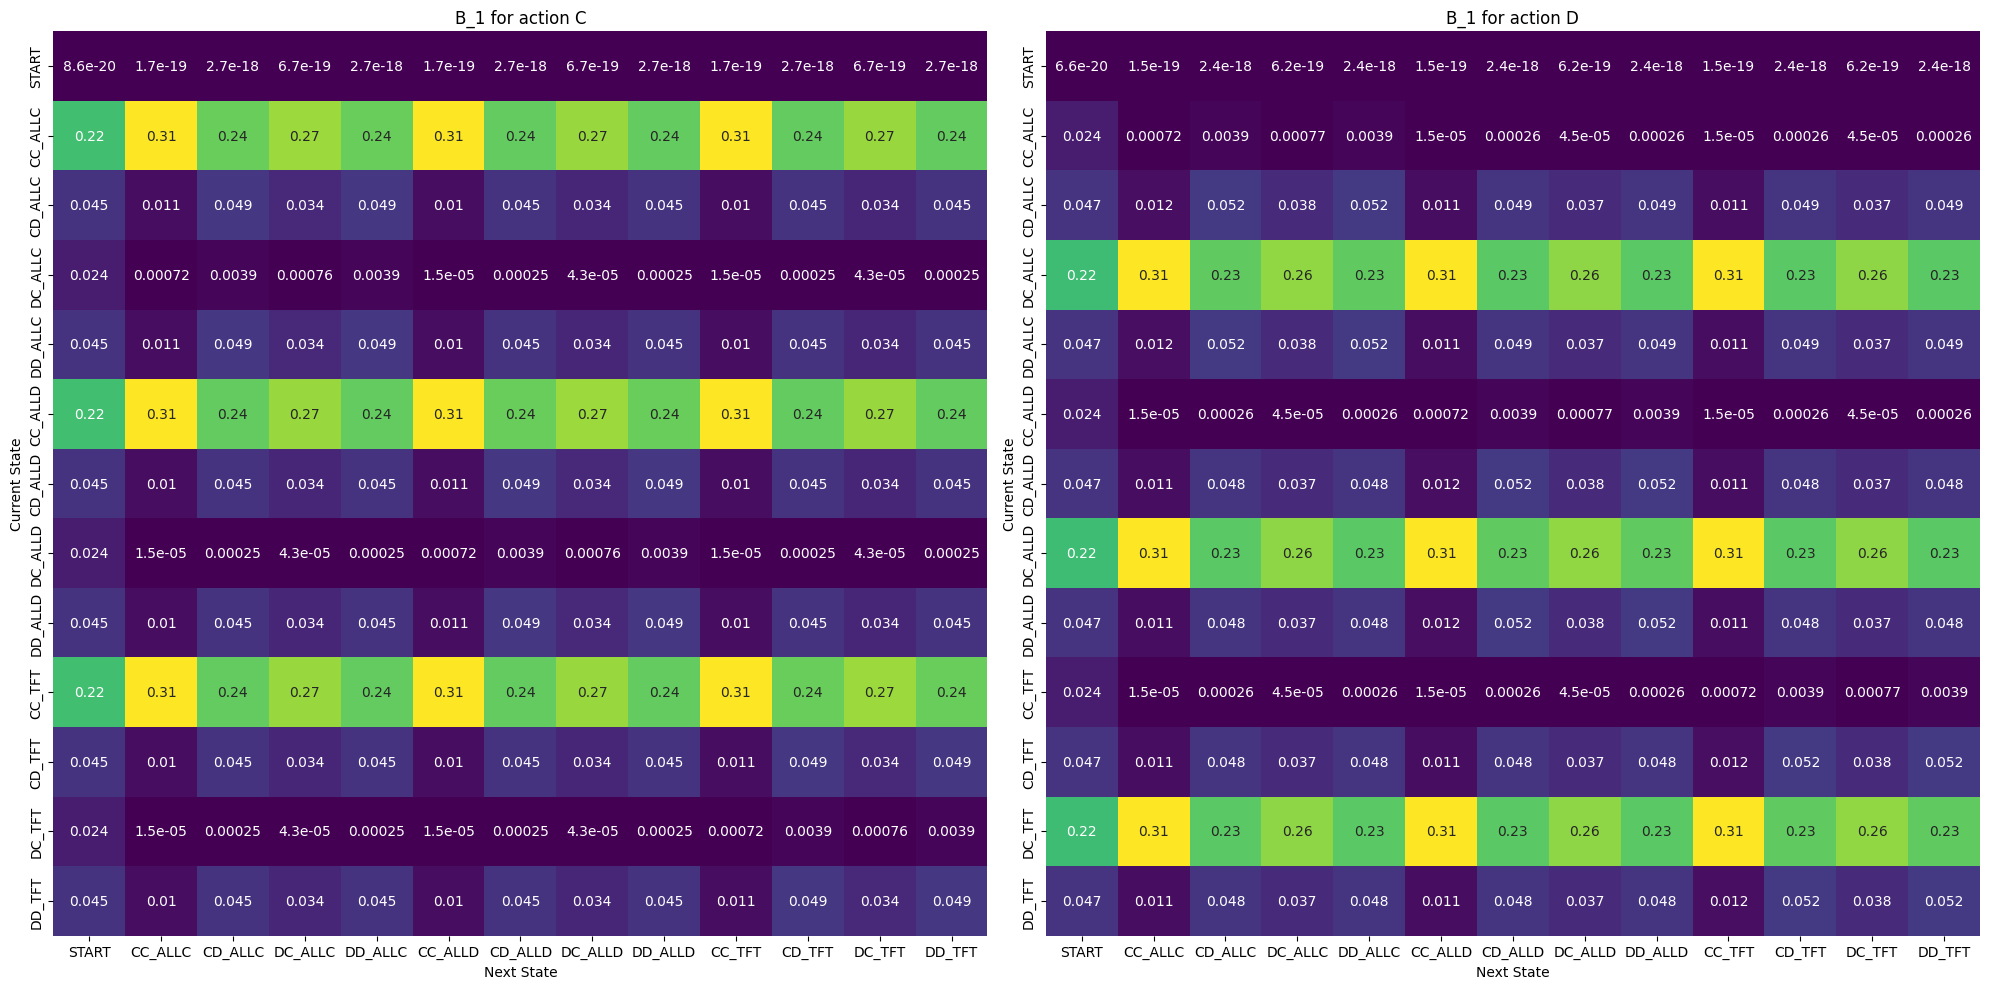

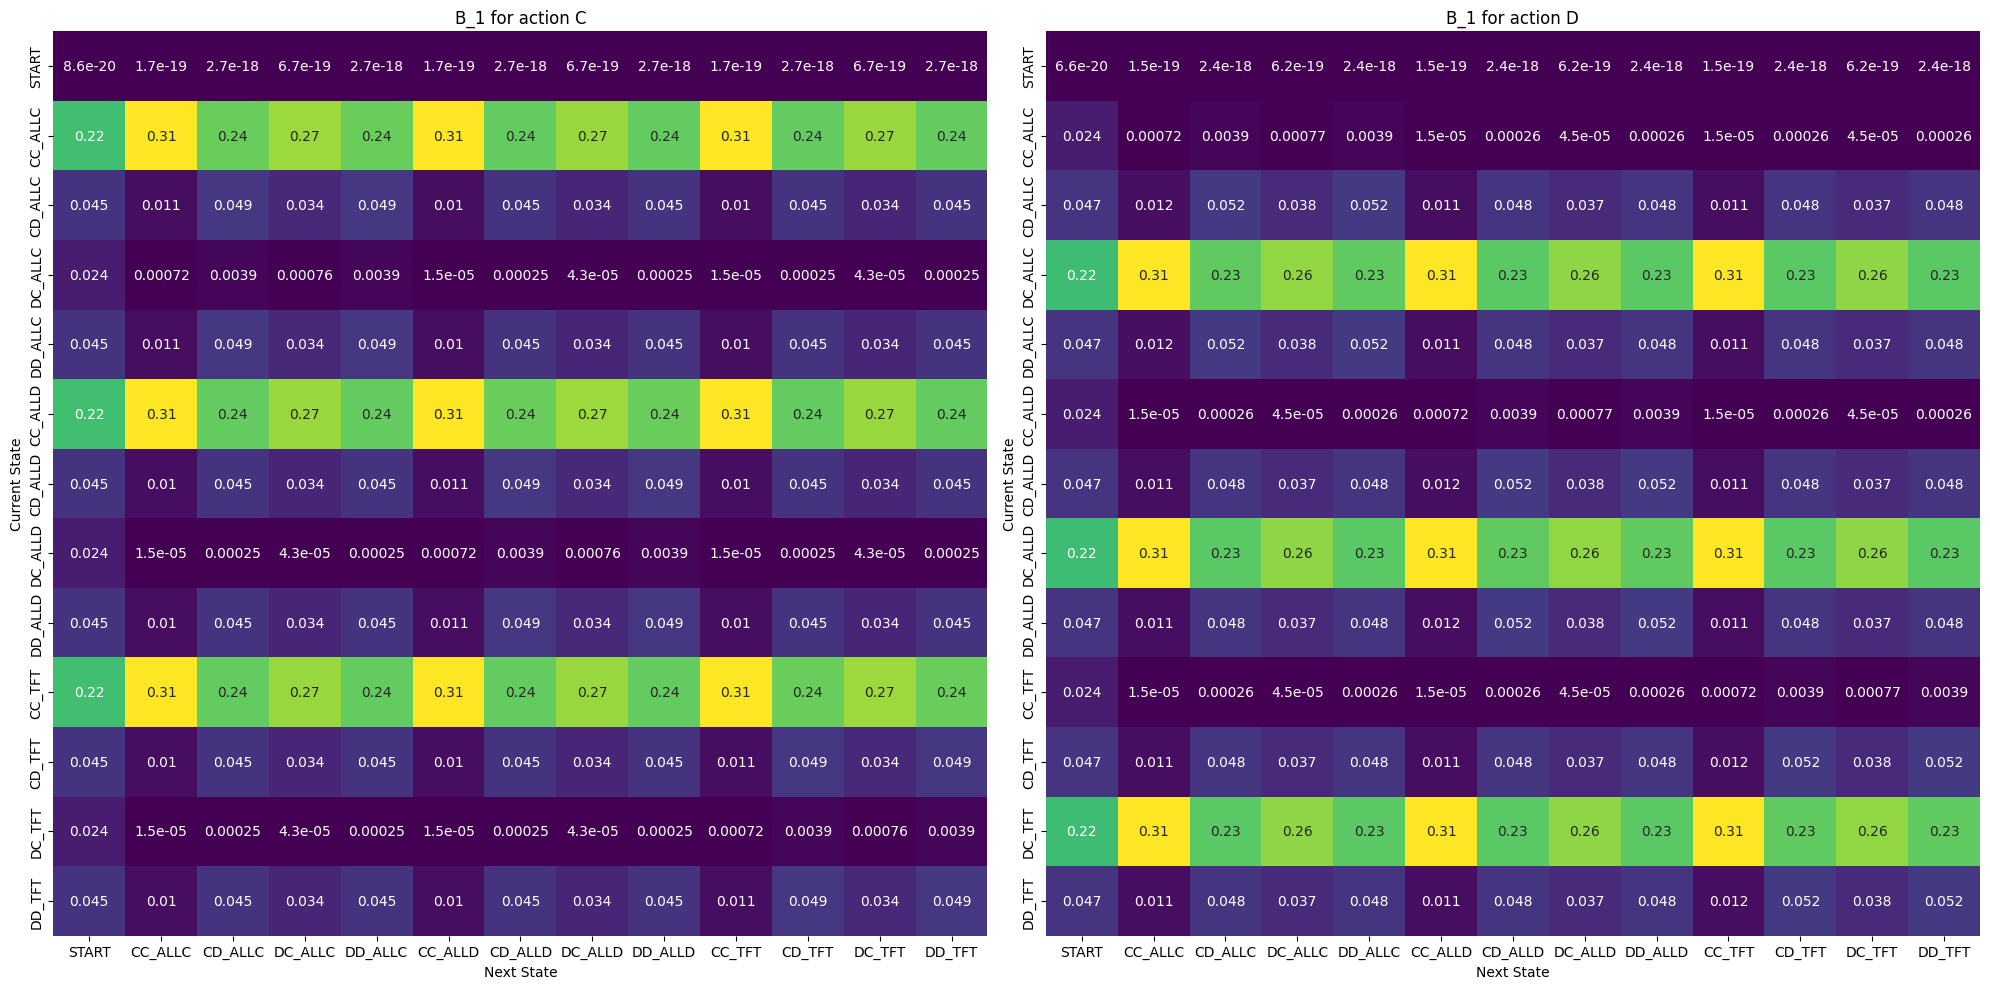

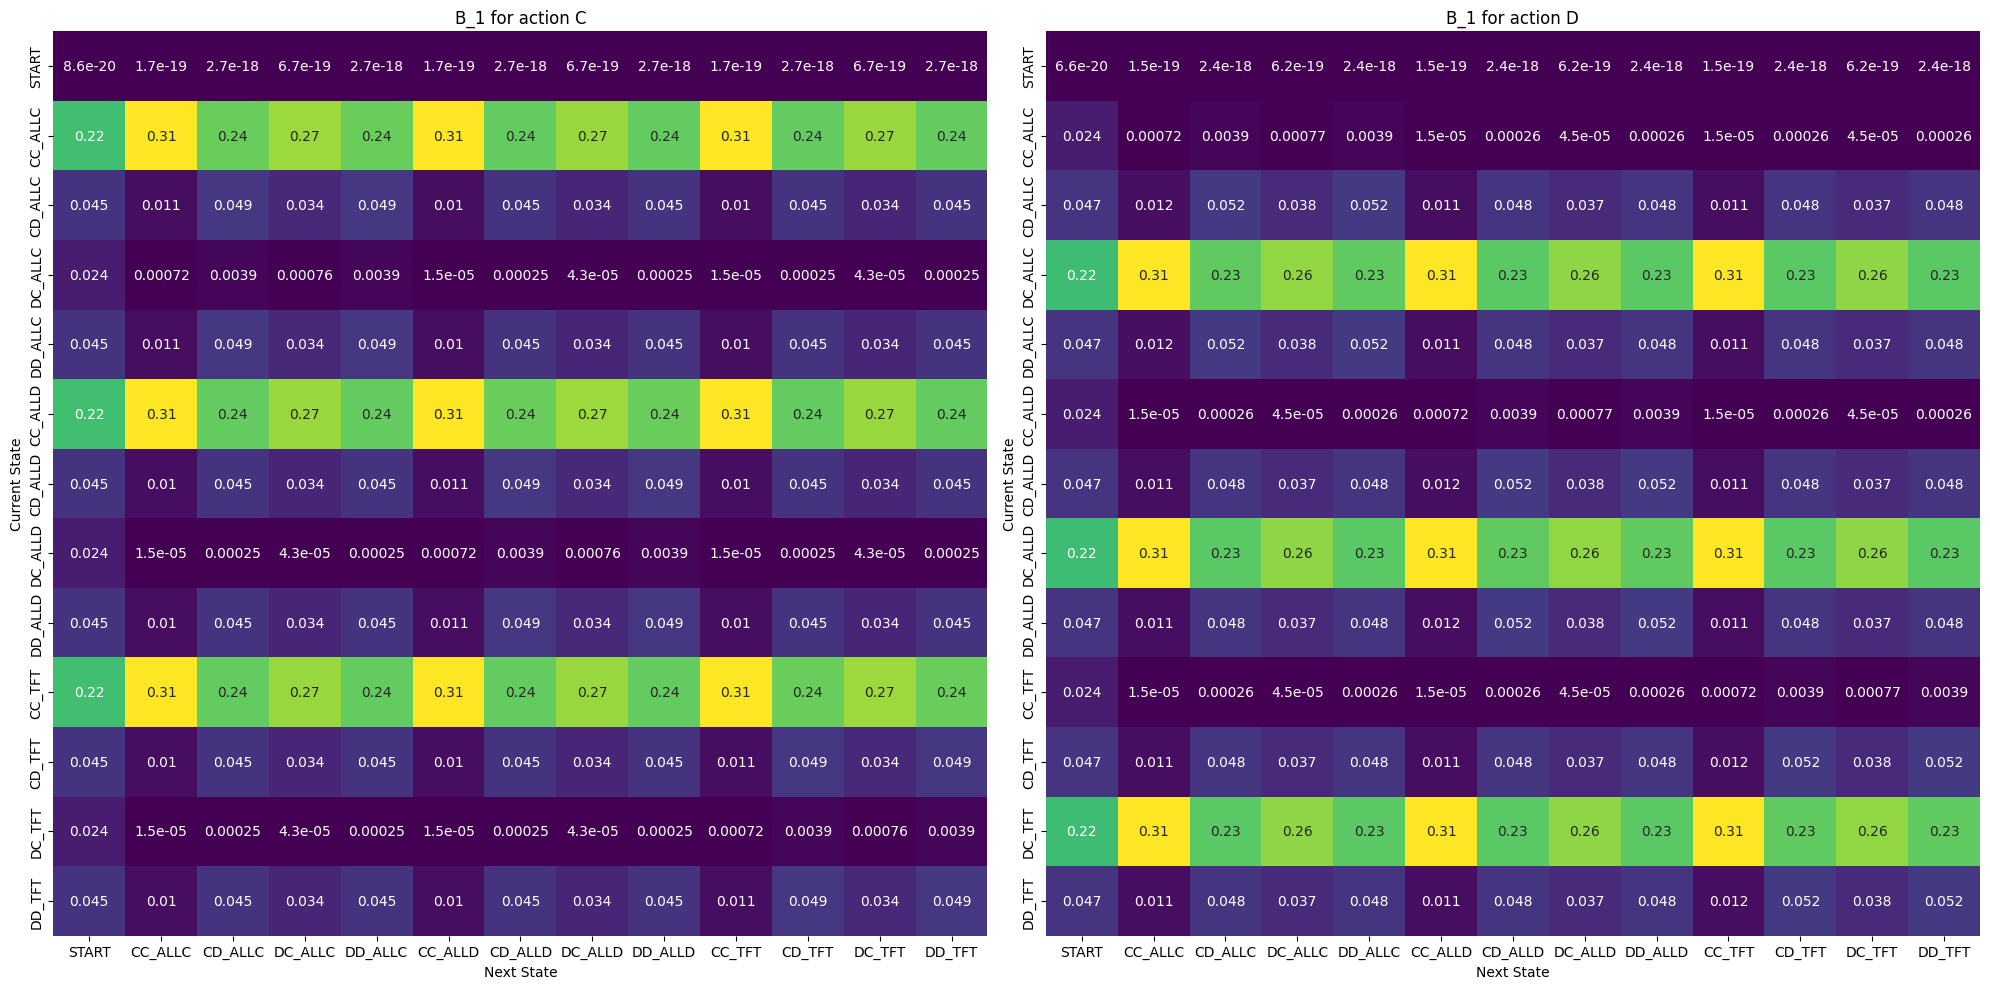

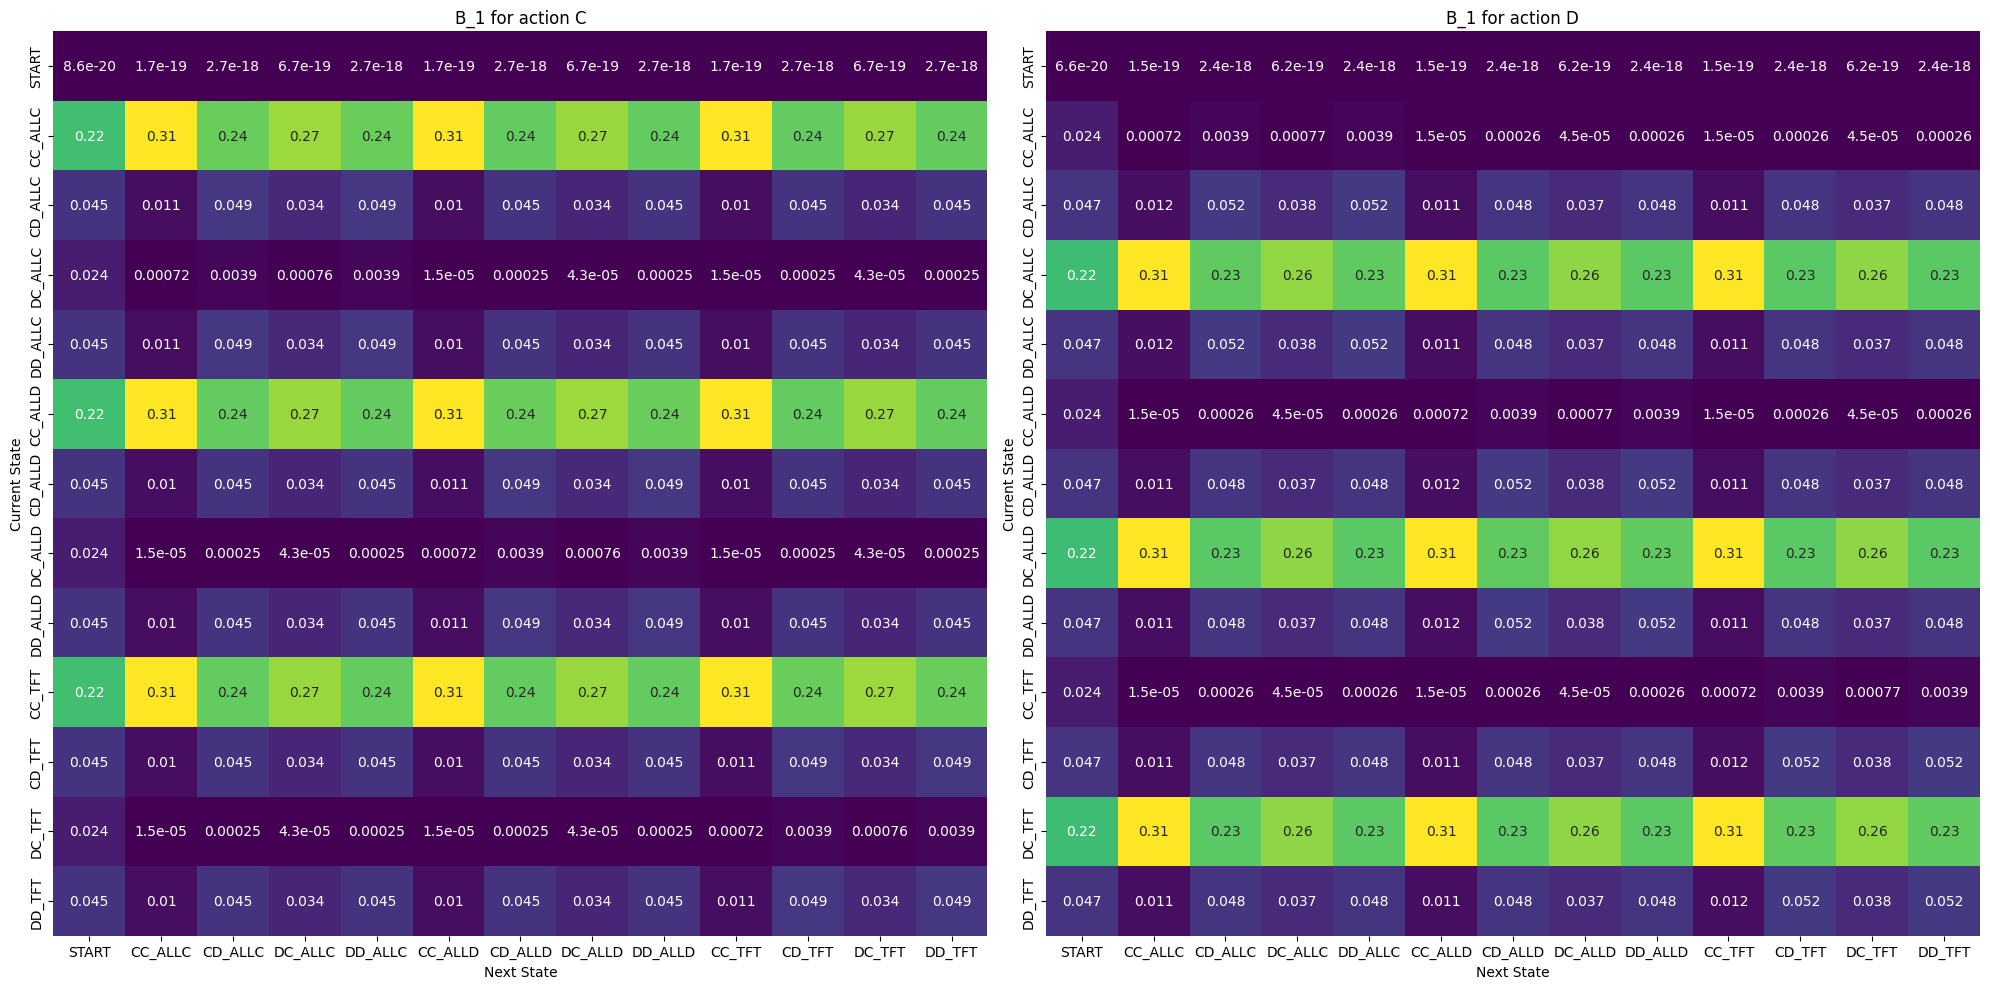

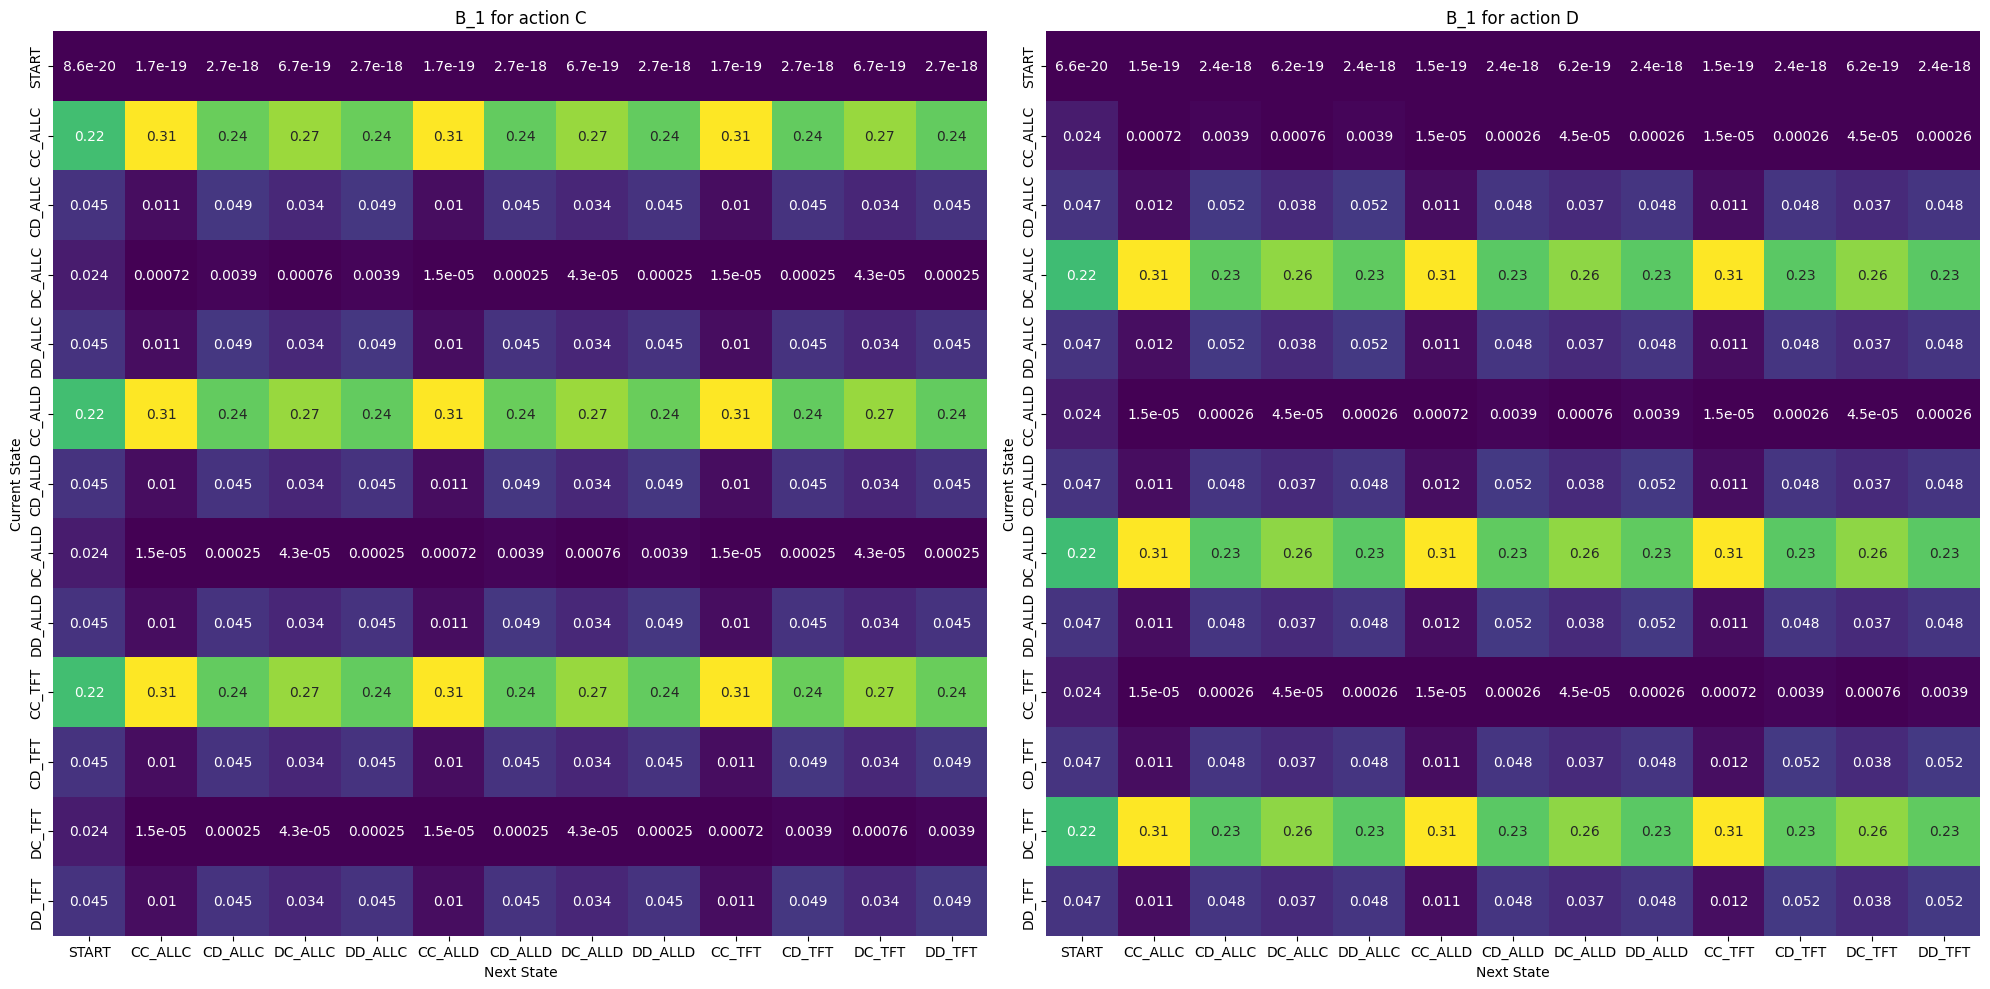

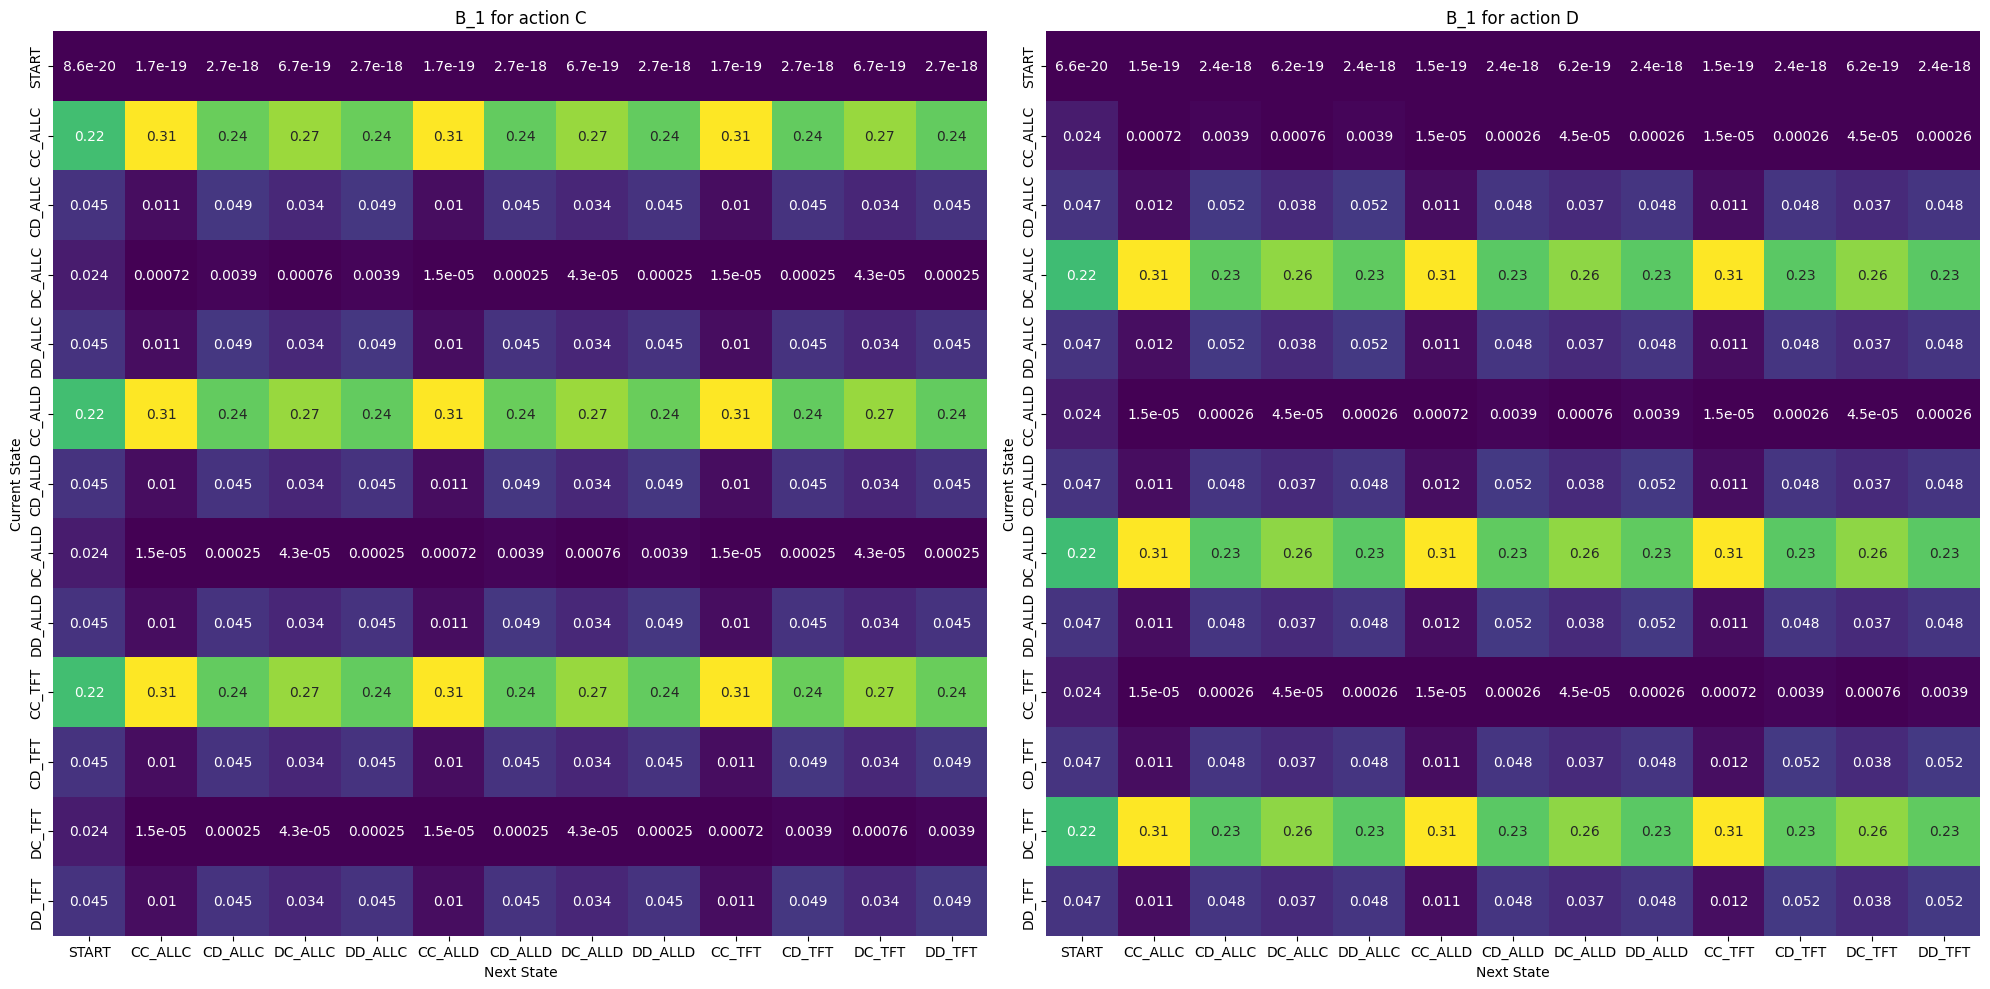

In [23]:
for B in Bs[-10:]:
    plot_B_1(B[0].reshape(num_states, num_states, num_actions))


In [24]:
obs[0]

def count_obs(obs):
    for o in obs:
        CC_count = 0
        CD_count = 0
        DC_count = 0
        DD_count = 0
        for i in o[0]:
            if i == 1:
                CC_count += 1
            elif i == 2:
                CD_count += 1
            elif i == 3:
                DC_count += 1
            elif i == 4:
                DD_count += 1
        print(CC_count, CD_count, DC_count, DD_count)

count_obs(obs)

483 0 516 0
478 0 521 0
535 0 464 0
493 0 506 0
231 265 266 237
254 264 265 216
252 247 247 253
0 506 0 493
245 256 257 241
518 0 481 0
463 0 536 0
520 0 479 0
233 264 265 237
511 0 488 0
0 502 0 497
0 512 0 487
0 482 0 517
267 249 249 234
261 237 237 264
0 489 0 510
522 0 477 0
268 250 251 230
276 255 255 213
275 239 239 246
0 483 0 516
0 511 0 488
230 239 239 291
0 515 0 484
248 259 259 233
488 0 511 0
0 516 0 483
0 508 0 491
272 245 246 236
257 242 242 258
492 0 507 0
504 0 495 0
0 510 0 489
0 470 0 529
256 239 239 265
245 258 258 238
504 0 495 0
0 507 0 492
0 499 0 500
286 247 248 218
498 0 501 0
515 0 484 0
231 256 256 256
242 253 254 250
234 257 257 251
0 481 0 518
221 261 261 256
0 486 0 513
0 501 0 498
503 0 496 0
485 0 514 0
260 243 244 252
501 0 498 0
0 499 0 500
505 0 494 0
232 255 255 257
235 262 262 240
259 257 258 225
0 517 0 482
512 0 487 0
505 0 494 0
0 496 0 503
272 241 242 244
296 229 229 245
516 0 483 0
237 245 245 272
244 237 237 281
503 0 496 0
0 475 0 524
0 479 0 

KeyboardInterrupt: 

In [25]:
agents[0].A

[Array([[[9.99938309e-01, 1.09238826e-07, 5.74671219e-07, 1.10980778e-07,
          5.74671219e-07, 1.09238748e-07, 5.74680939e-07, 1.10980800e-07,
          5.74680939e-07, 1.09238862e-07, 5.74691057e-07, 1.10980999e-07,
          5.74691057e-07],
         [1.53834299e-05, 5.81984043e-01, 2.16015428e-02, 1.27735211e-06,
          2.16015428e-02, 5.82006037e-01, 2.16024723e-02, 1.27735984e-06,
          2.16024723e-02, 5.82029462e-01, 2.16033533e-02, 1.27737019e-06,
          2.16033533e-02],
         [1.53834299e-05, 4.17776972e-01, 4.57986087e-01, 2.32558465e-04,
          4.57986087e-01, 4.17755008e-01, 4.57991153e-01, 2.32551596e-04,
          4.57991153e-01, 4.17731673e-01, 4.57993925e-01, 2.32544975e-04,
          4.57993925e-01],
         [1.53834299e-05, 1.31253375e-06, 2.17099506e-02, 5.91148853e-01,
          2.17099506e-02, 1.31253853e-06, 2.17106268e-02, 5.91169834e-01,
          2.17106268e-02, 1.31254865e-06, 2.17113476e-02, 5.91193140e-01,
          2.17113476e-02],
    

In [26]:
agents[0].C

[Array([[ 0., 10.,  0.,  0.,  9.]], dtype=float32)]

In [27]:
agents[0].D

[Array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)]

In [31]:
agent = AIFAgent(
    A = agents[0].A,
    B = agents[0].B,
    C = agents[0].C,
    D = agents[0].D,
    pA = agents[0].pA,
    pB = agents[0].pB,
    E = None,
    policy_len=4,
    use_utility=True,
    use_states_info_gain=False,
    use_param_info_gain=False,
    gamma=jnp.ones(1),
    alpha=jnp.ones(1),
    onehot_obs=False,
    action_selection="deterministic",
    inference_algo="ovf",
)

(13,)


JitTracer<int32[]>
{'empirical_prior': [JitTracer<float32[1,13]>], 'obs': [JitTracer<int32[1,1]>], 'rng_key': JitTracer<uint32[2]>}
[JitTracer<float32[1,1,13]>]
JitTracer<float32[1,16]>
JitTracer<int32[1,1]>
JitTracer<int32[1,1]>
[JitTracer<int32[1,1]>]
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD
CD


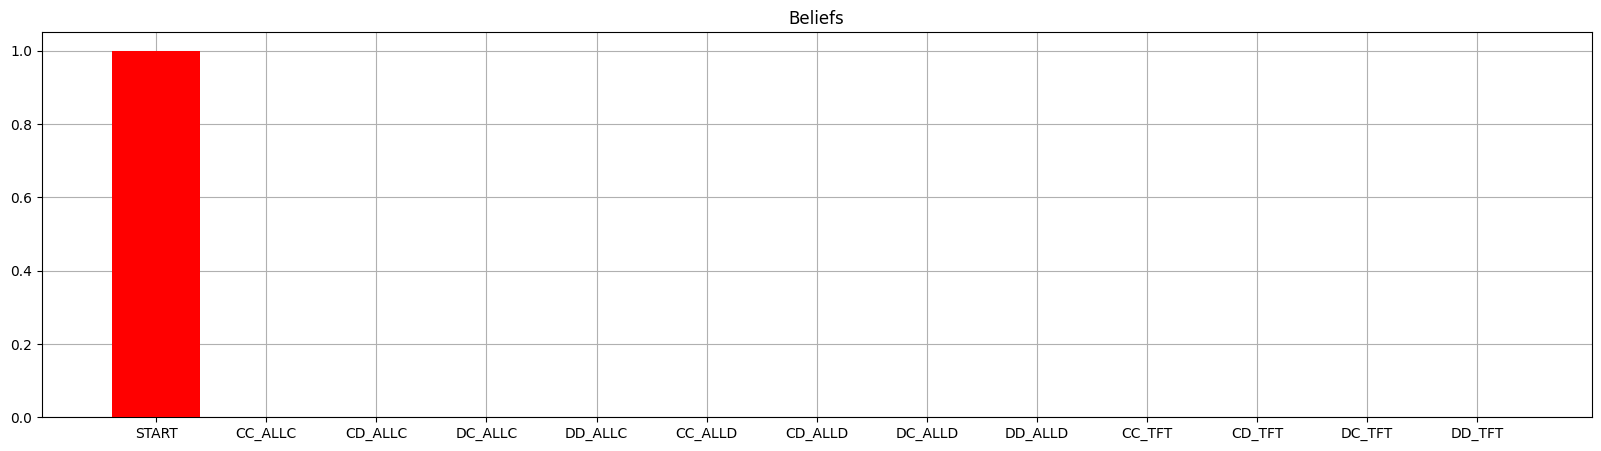

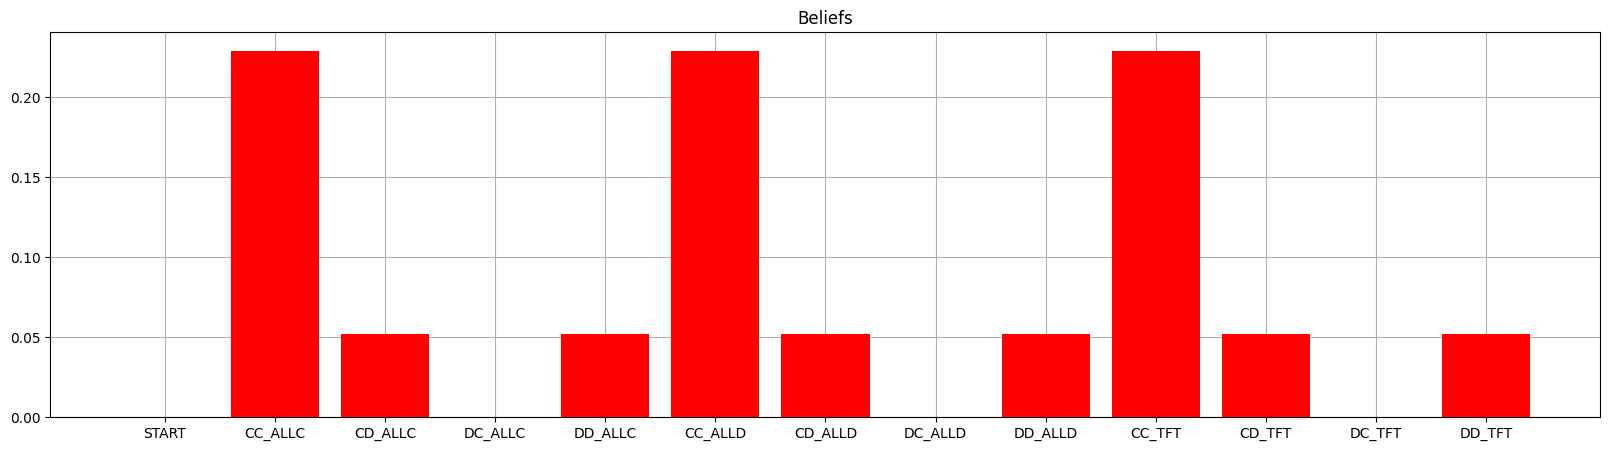

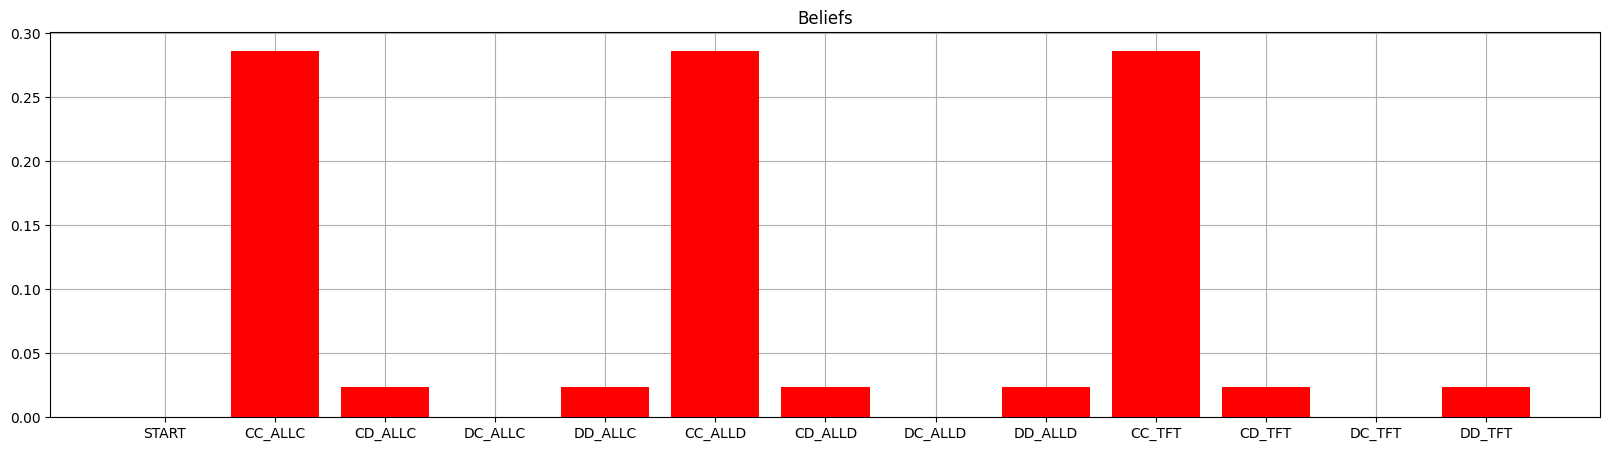

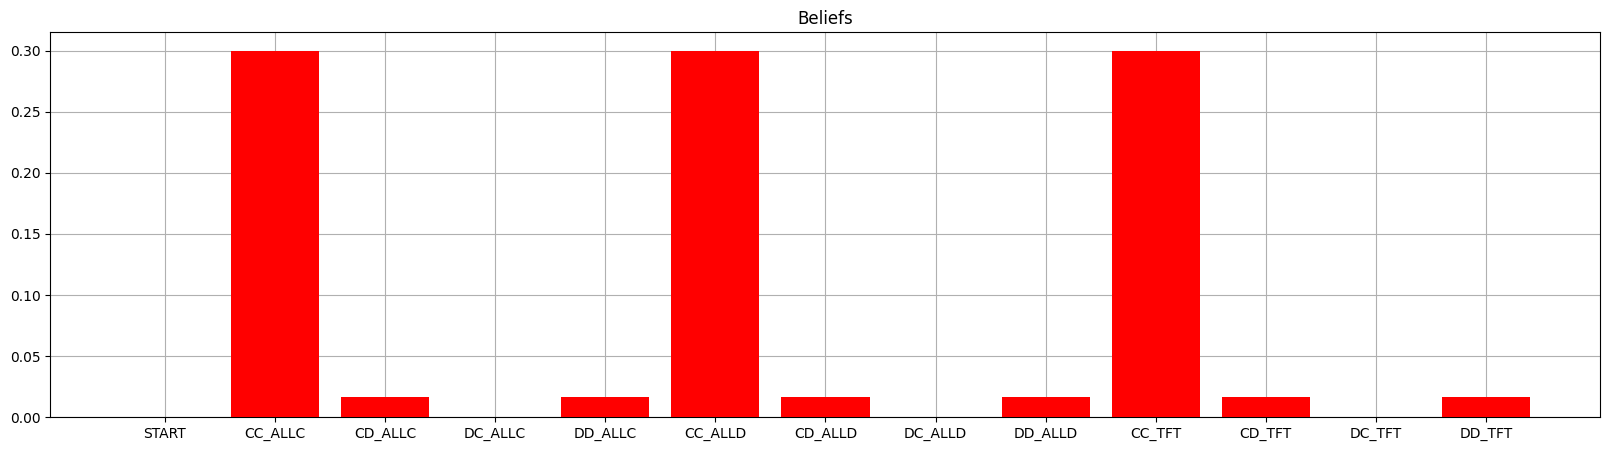

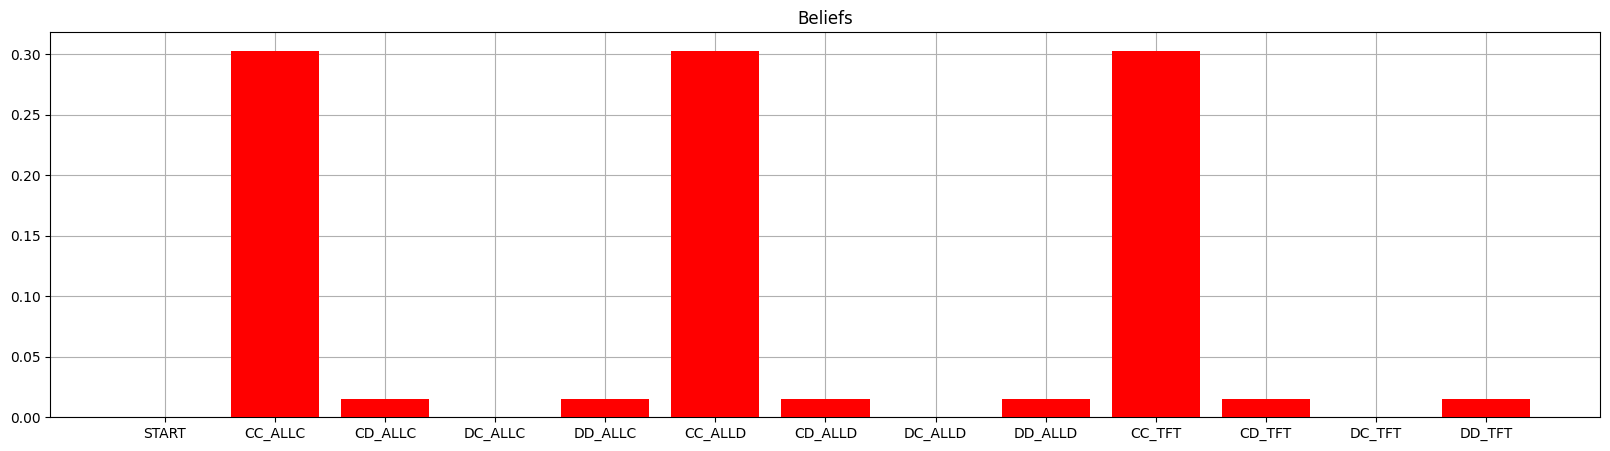

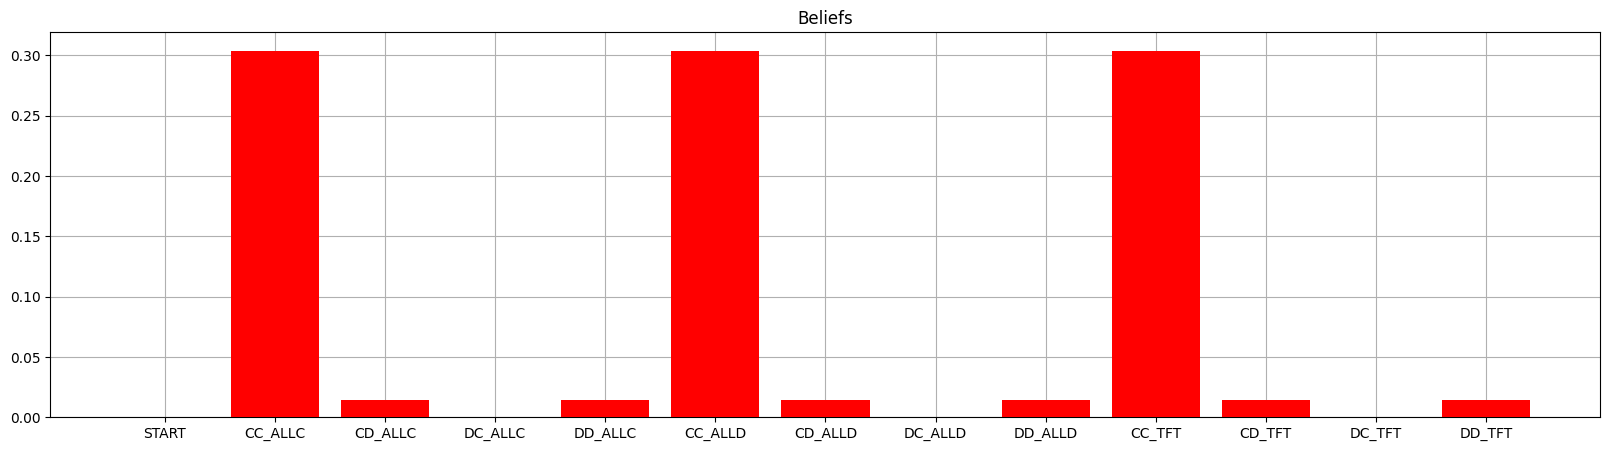

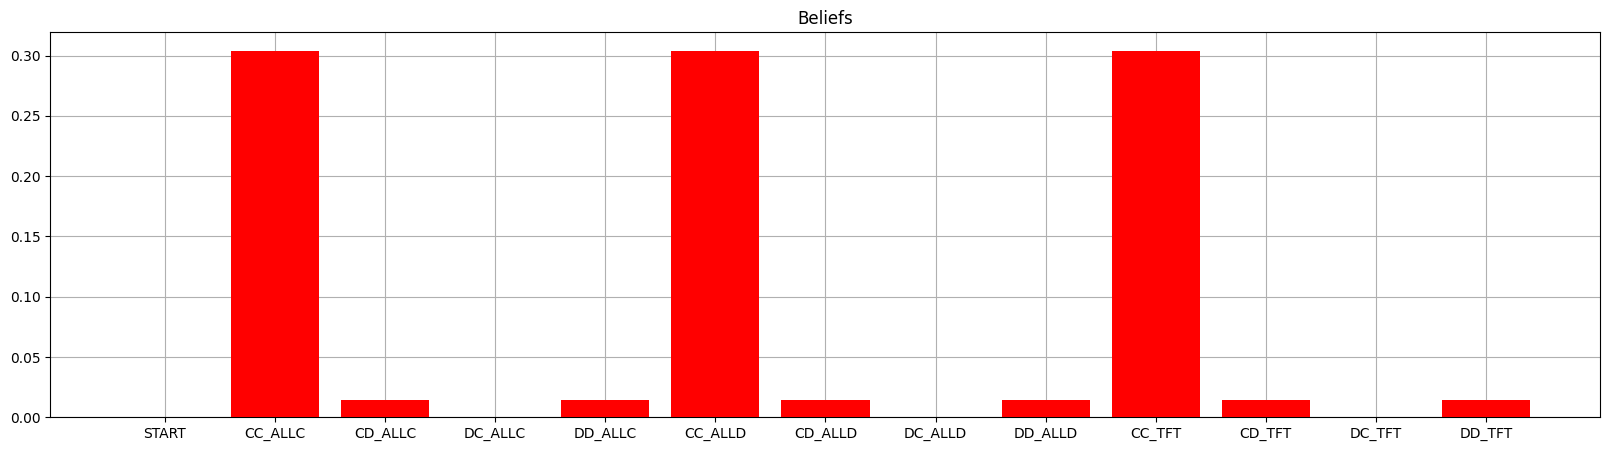

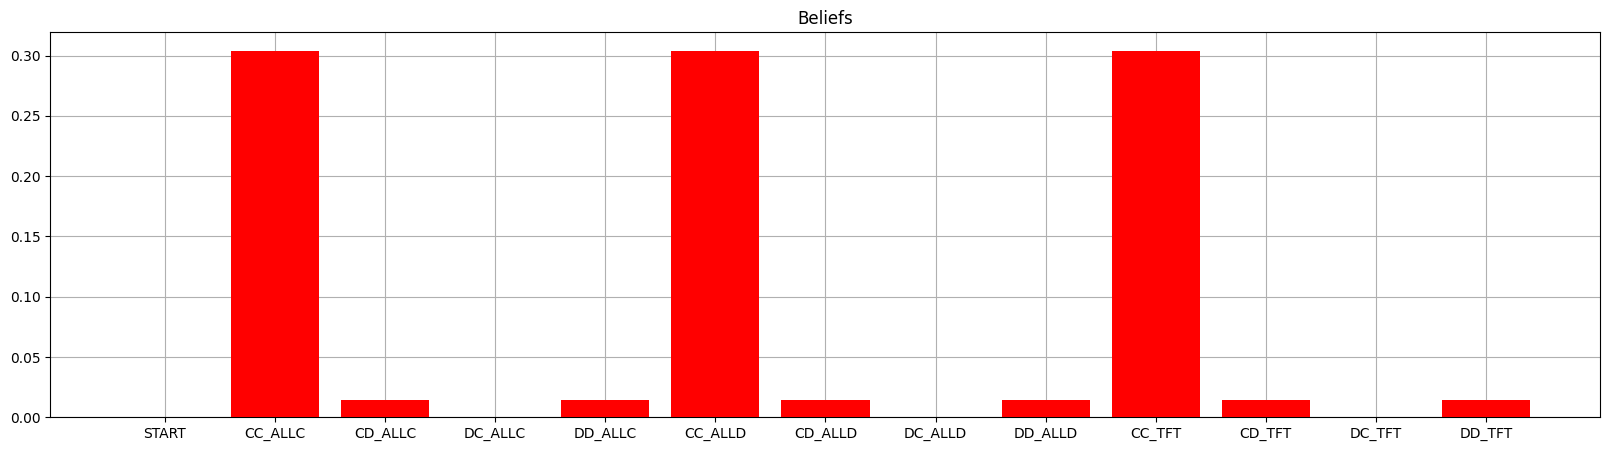

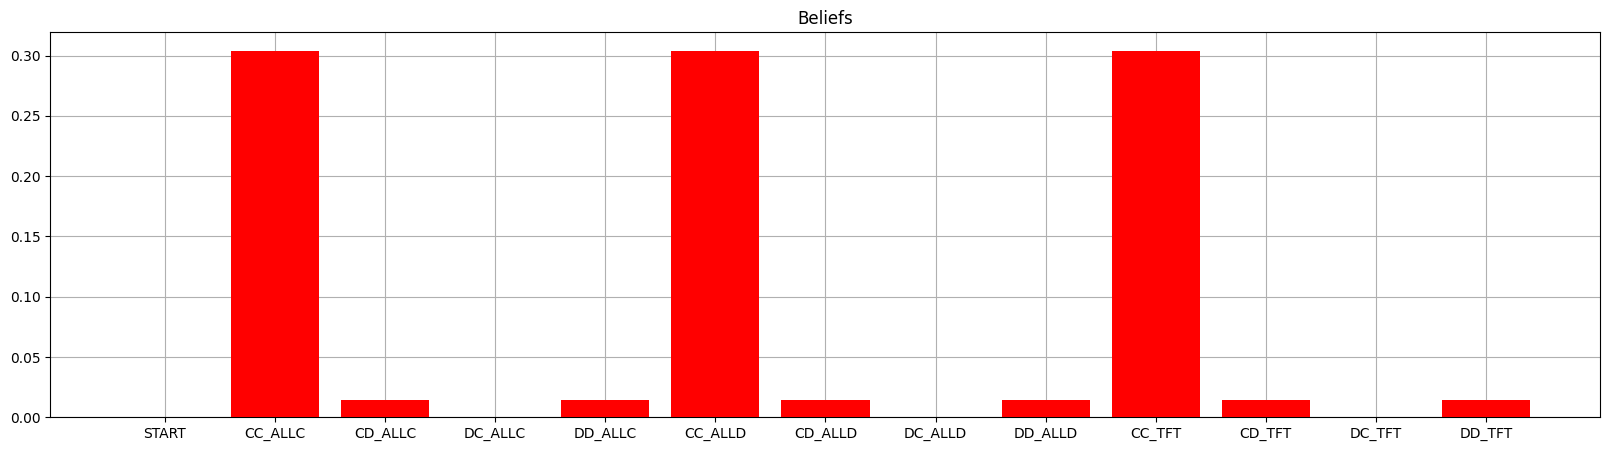

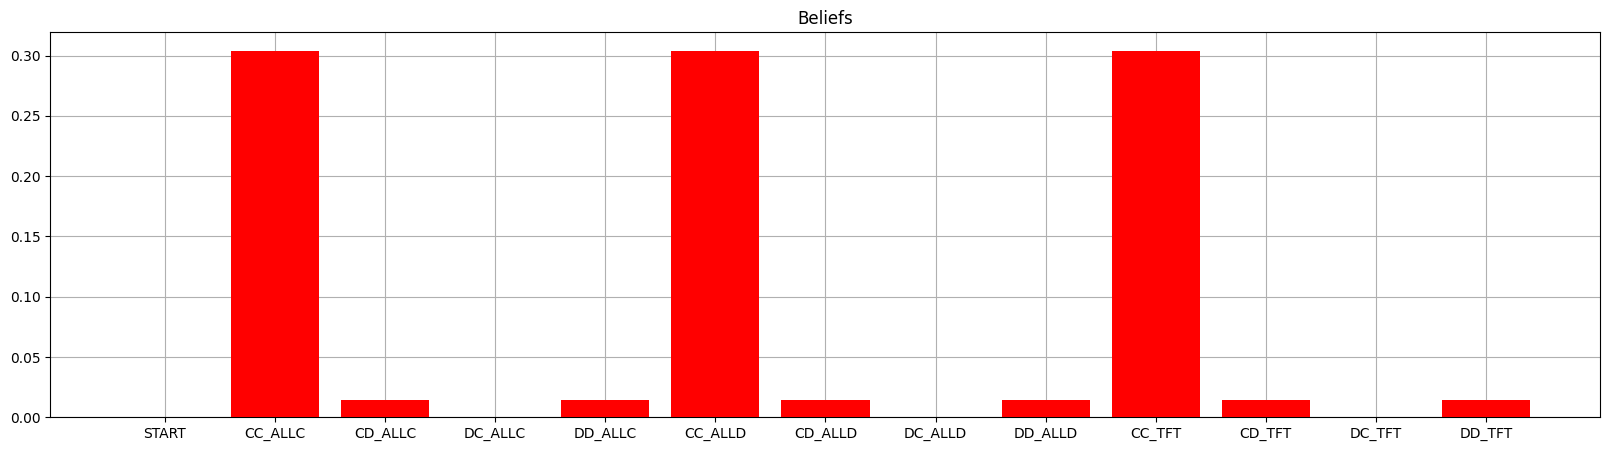

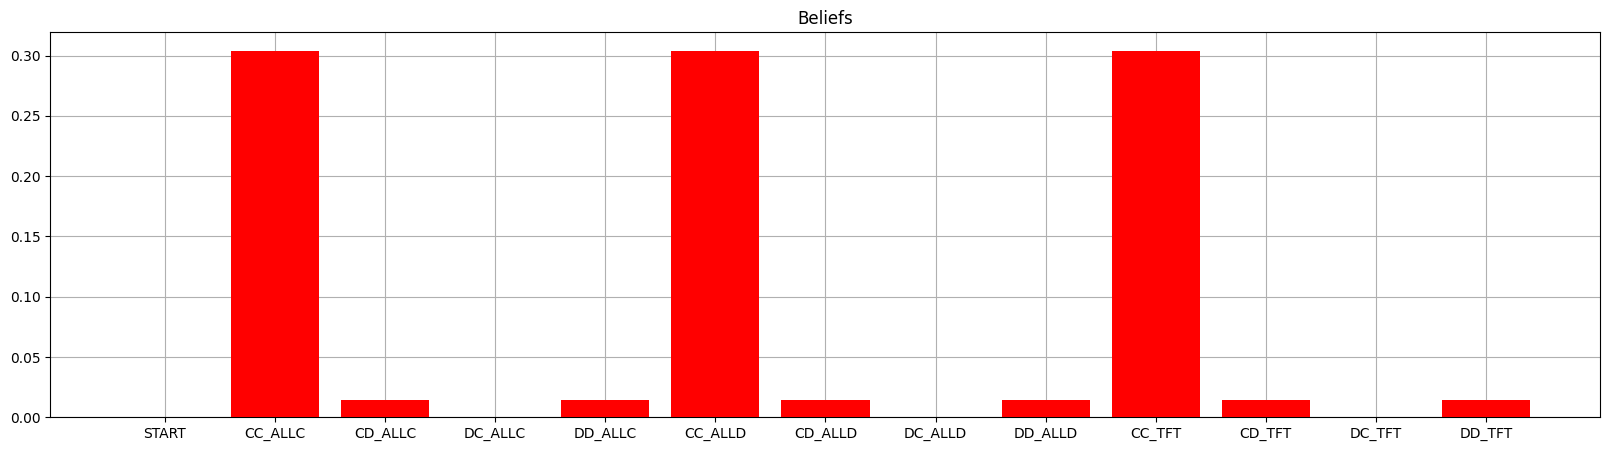

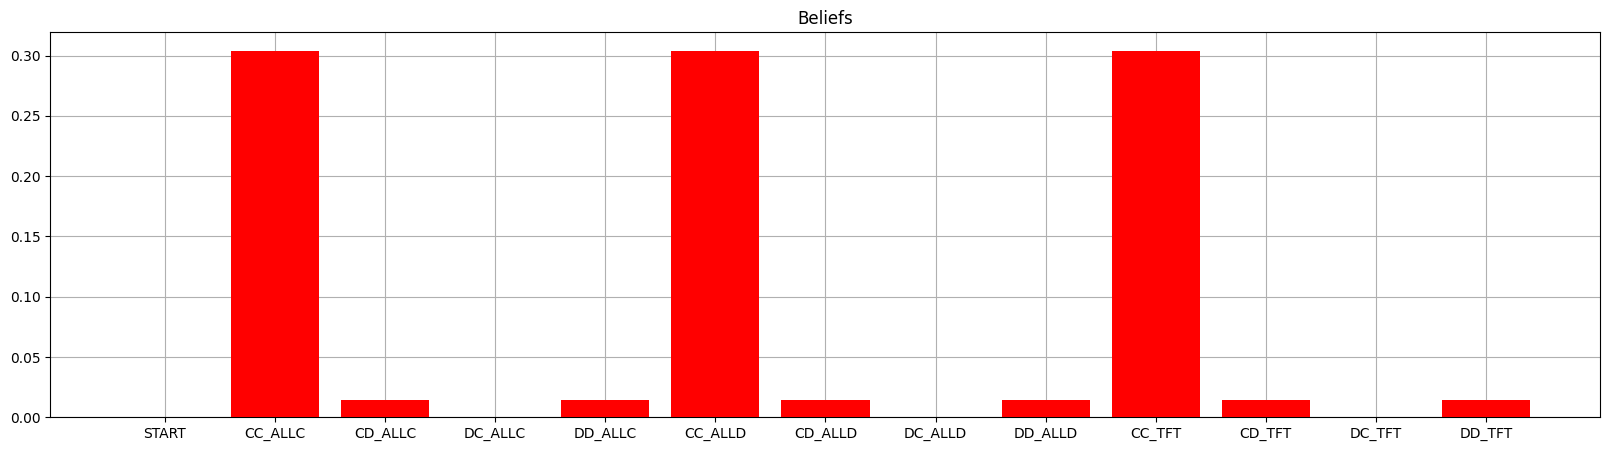

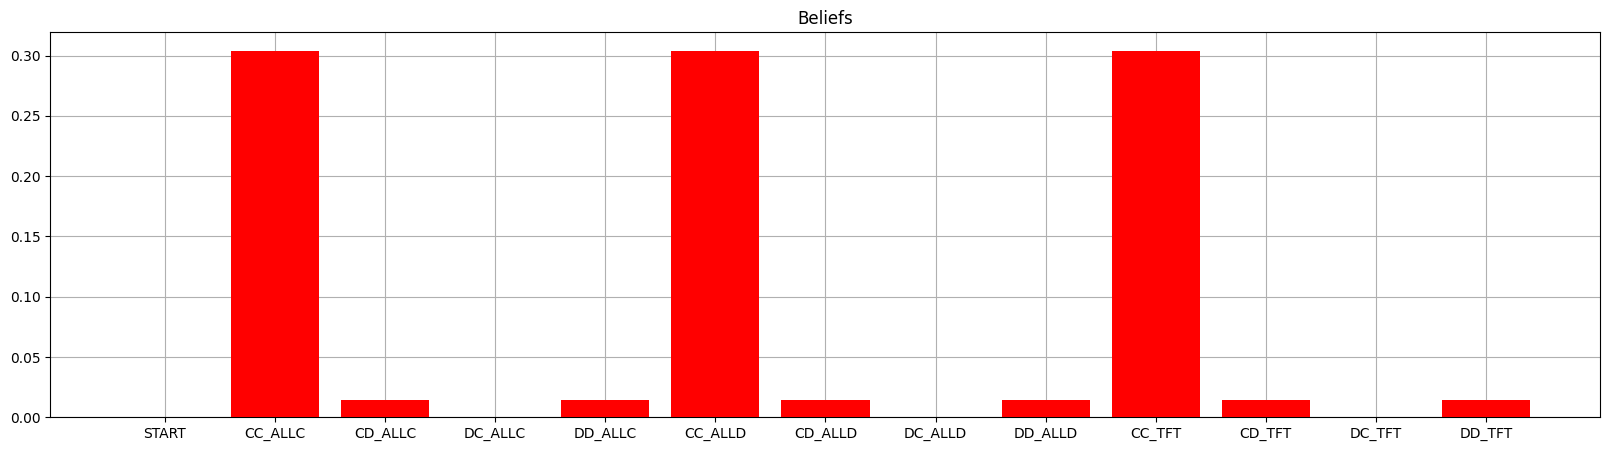

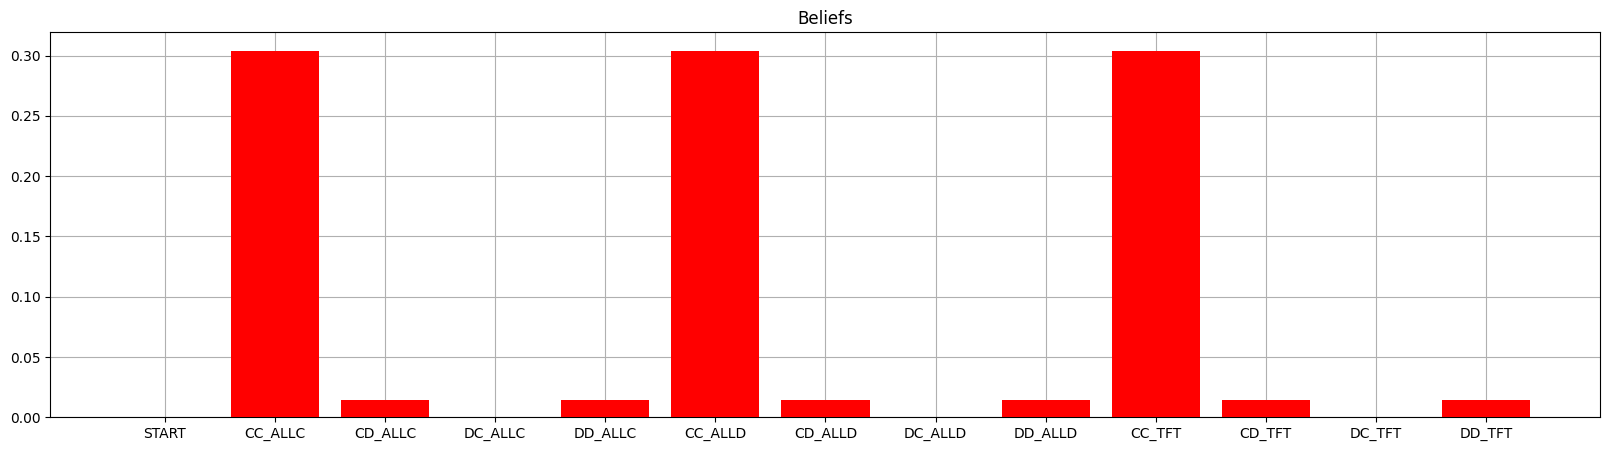

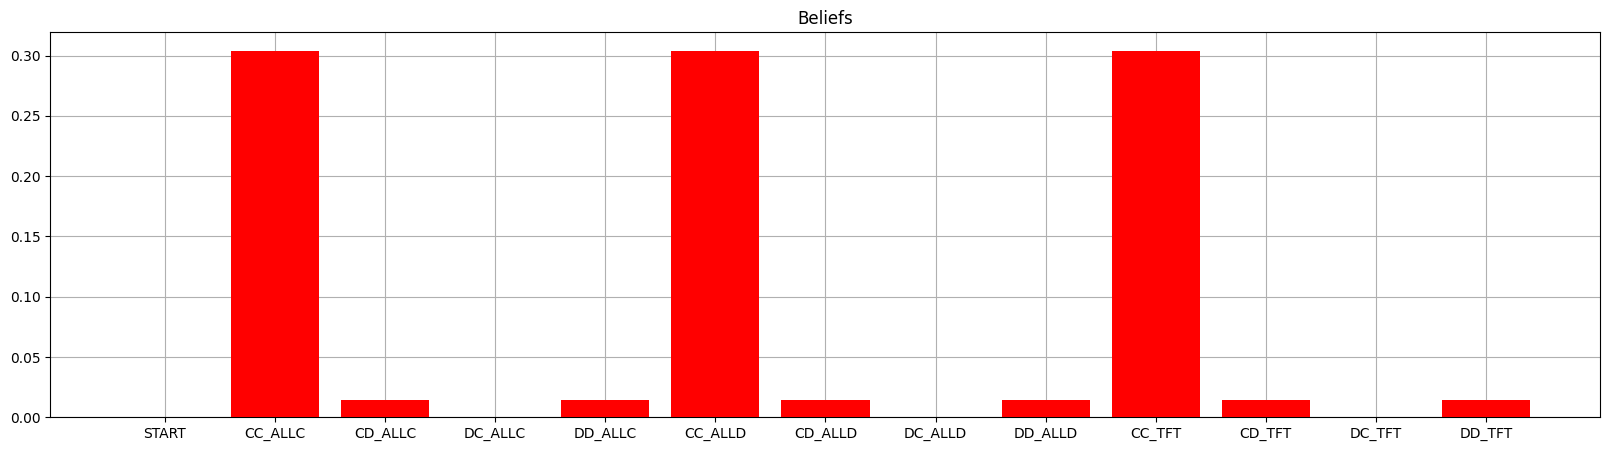

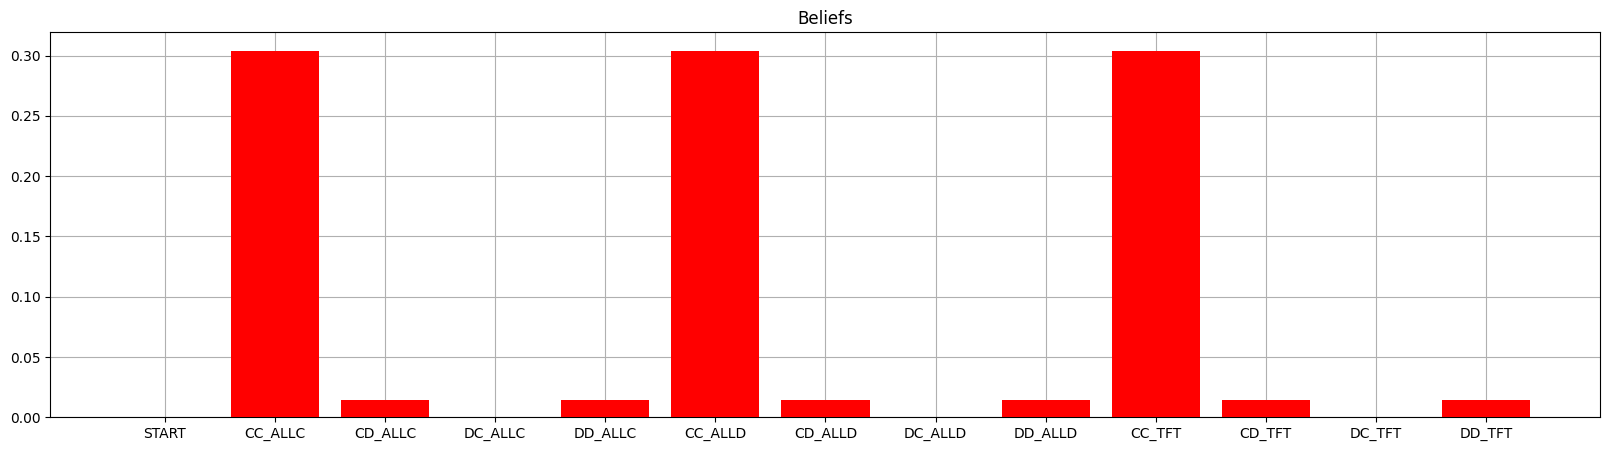

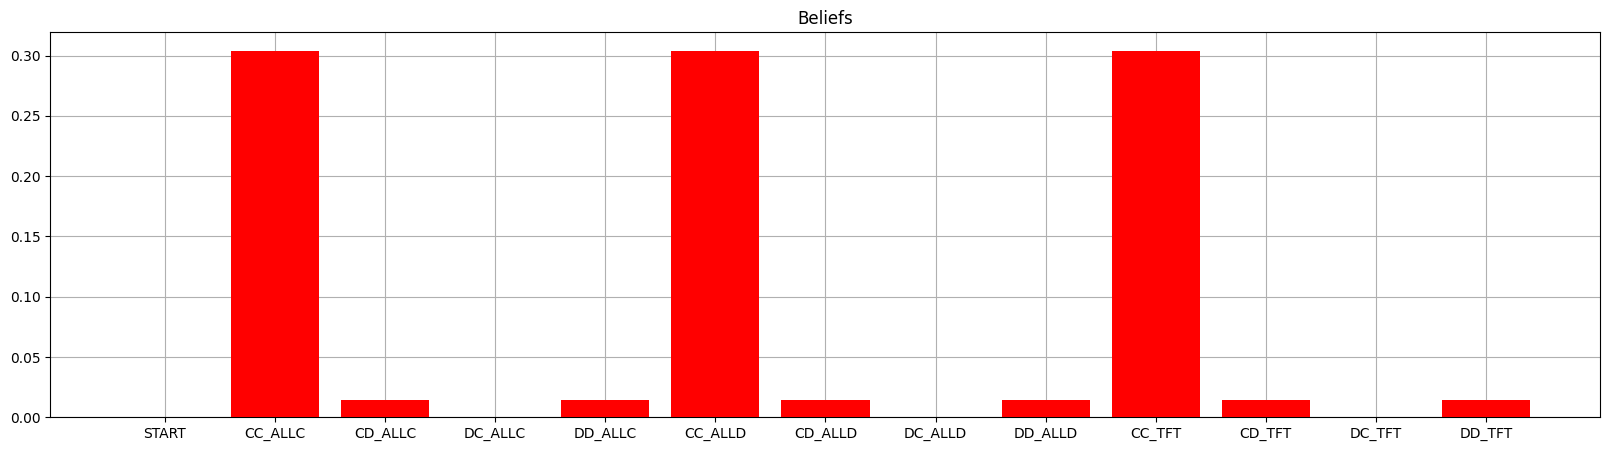

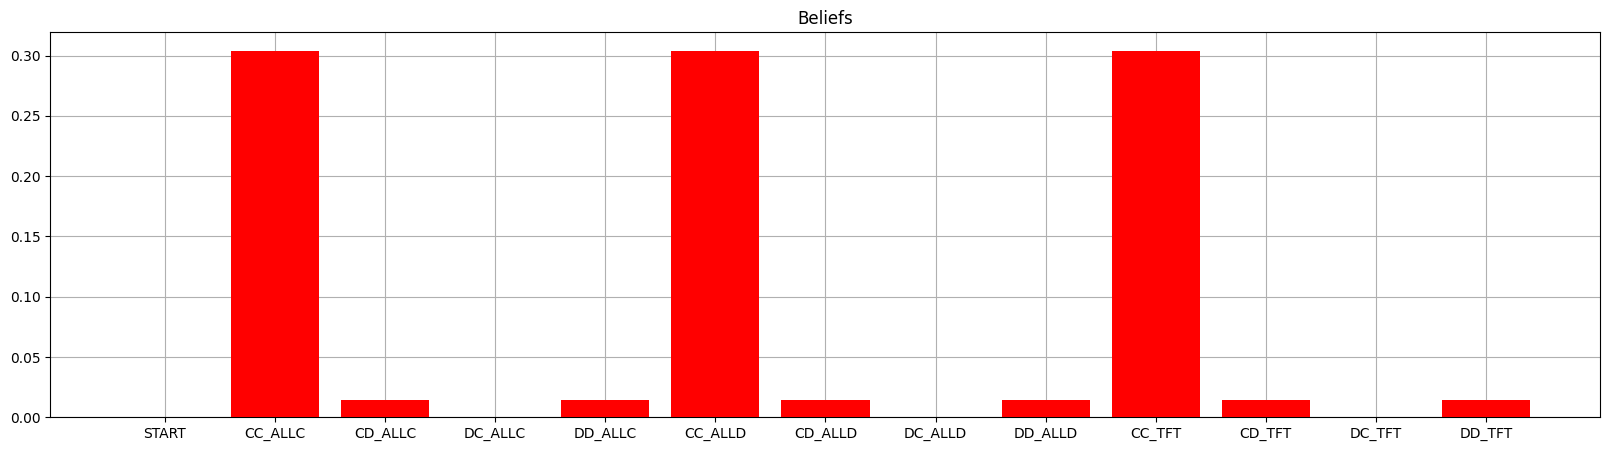

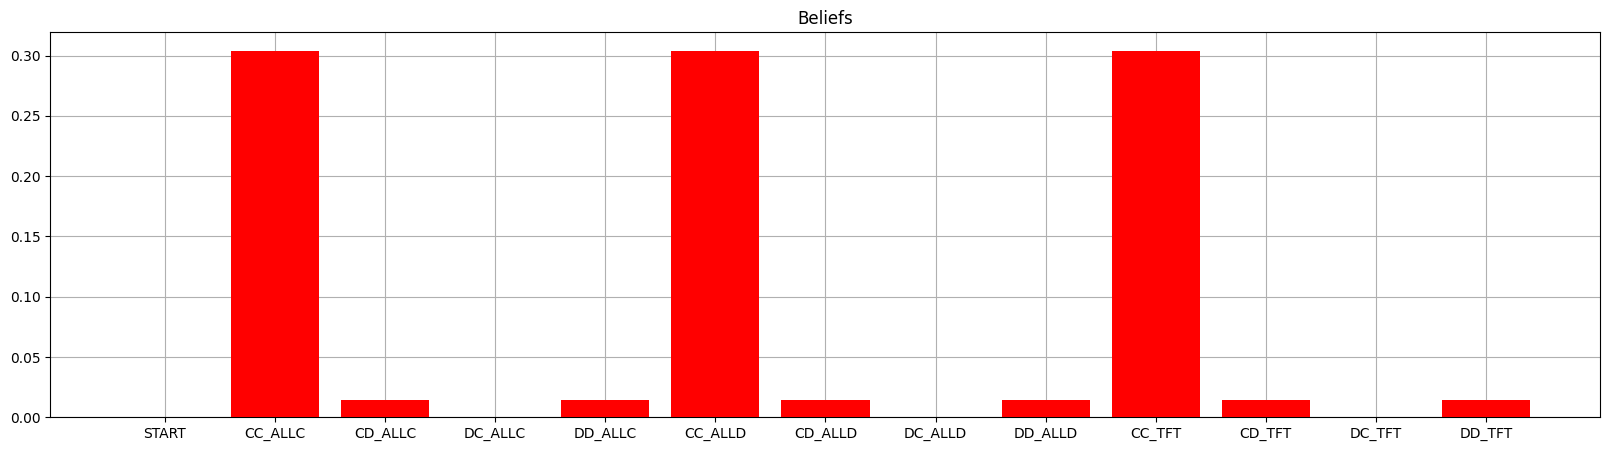

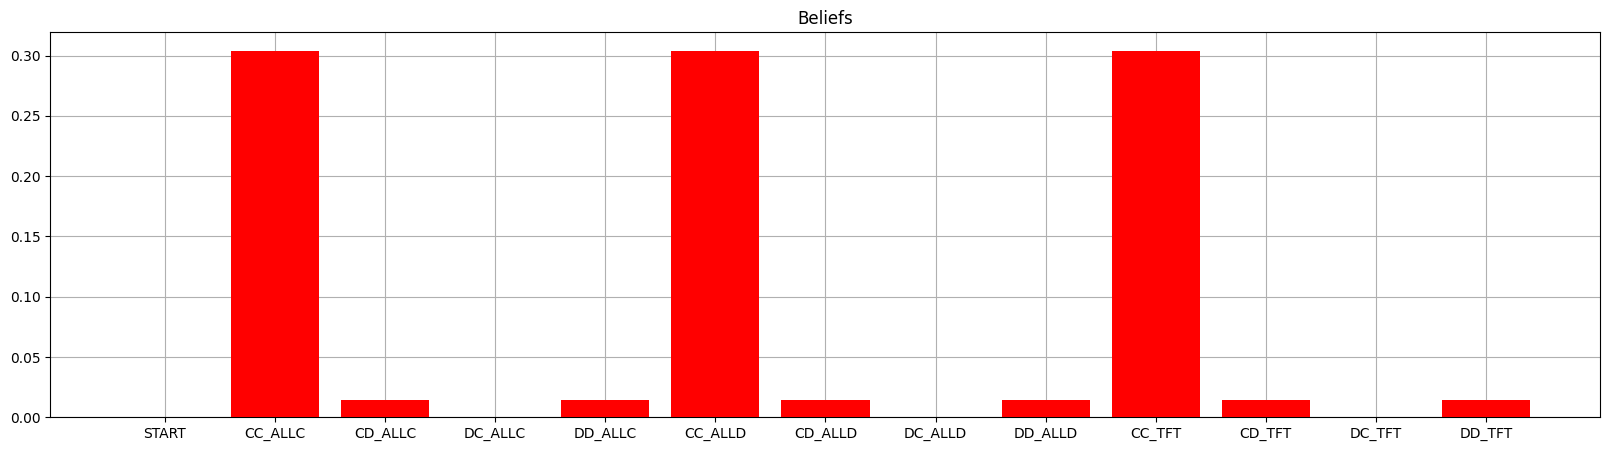

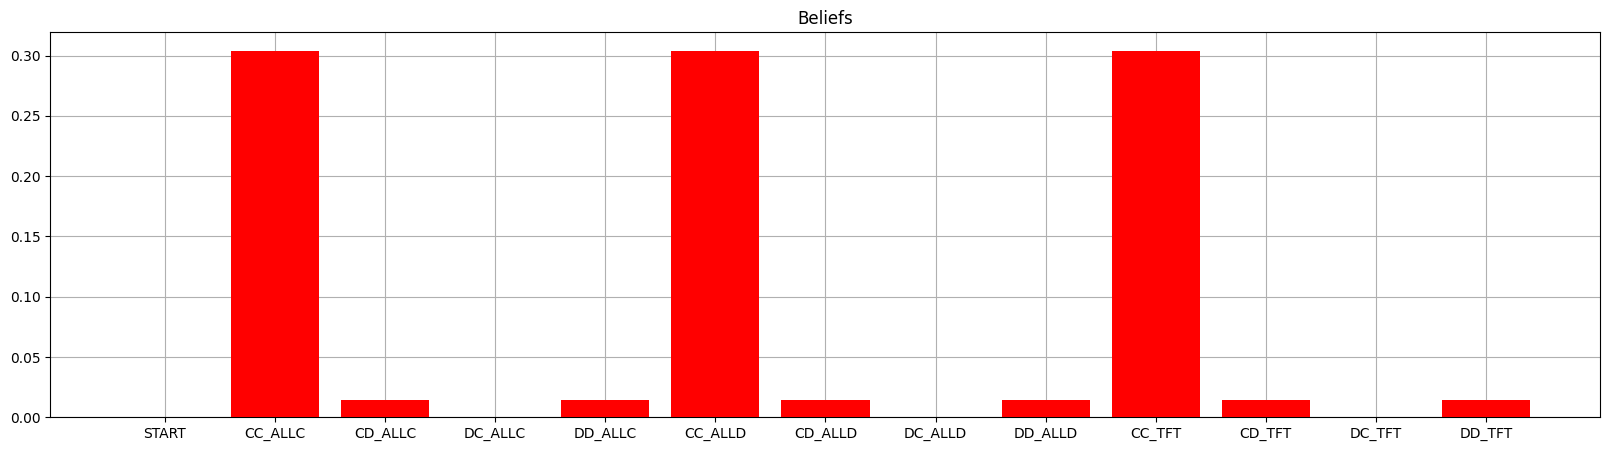

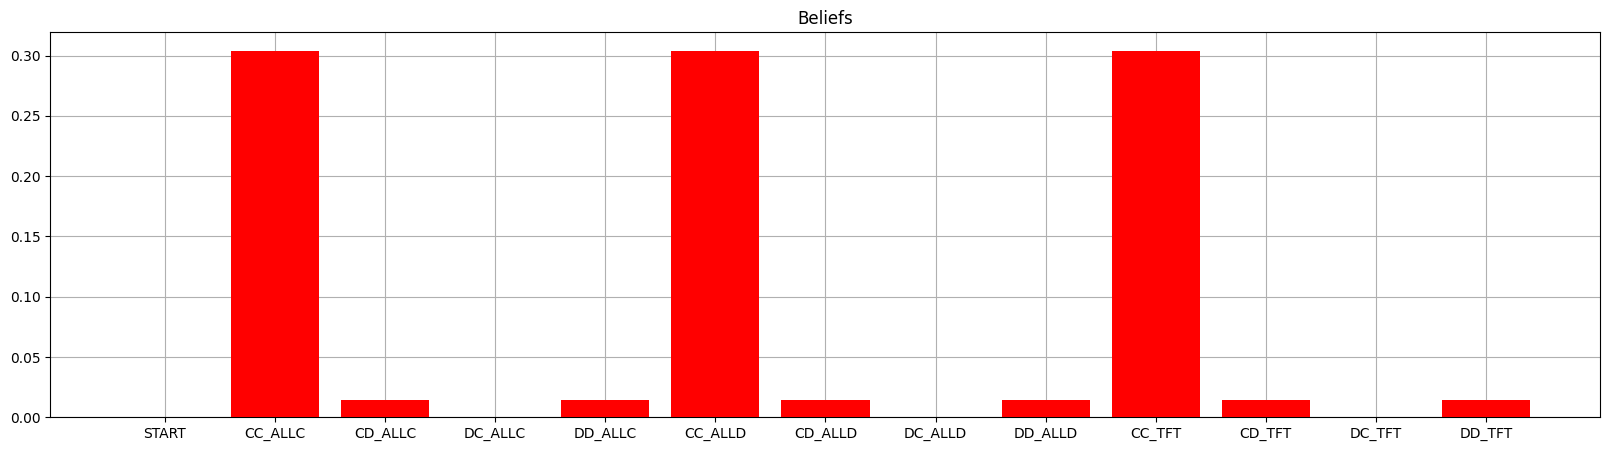

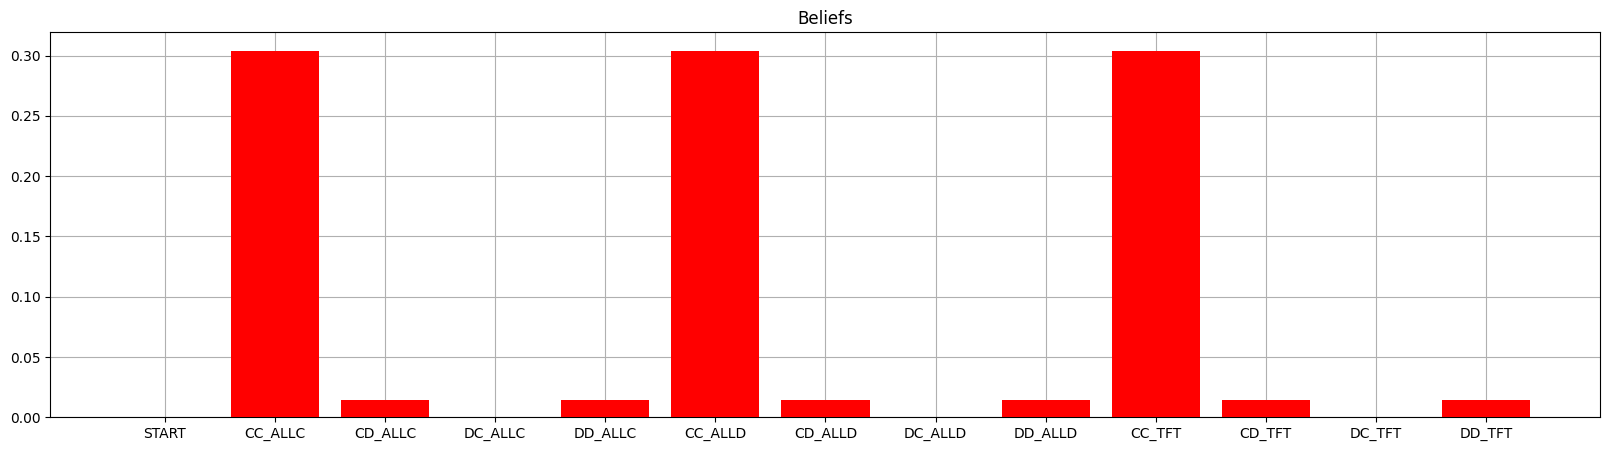

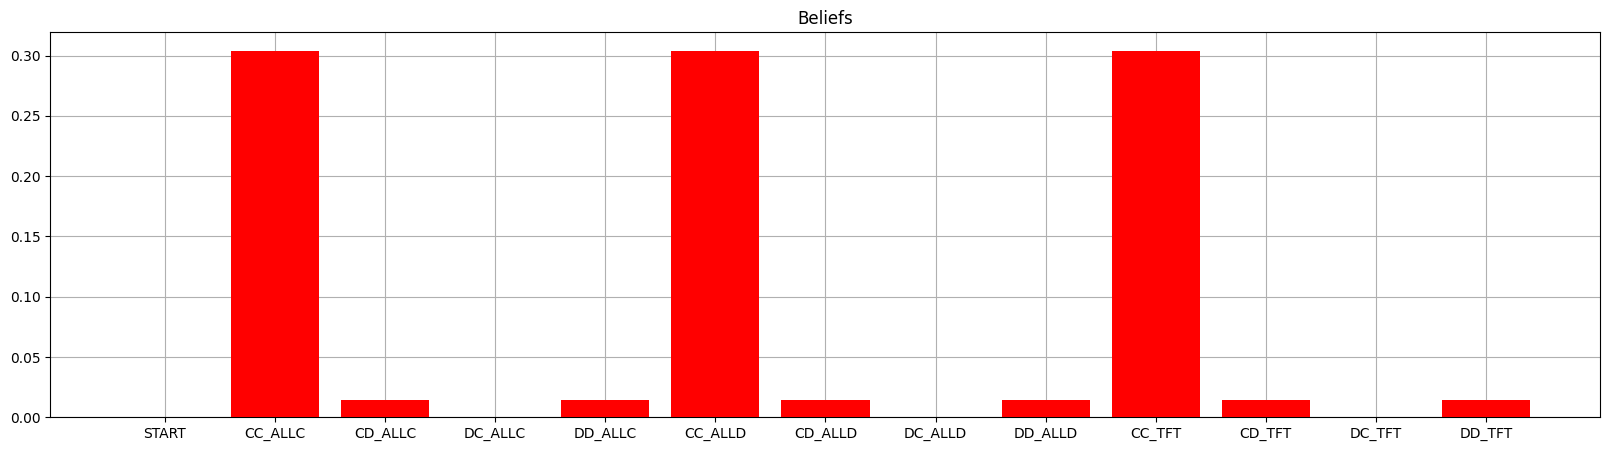

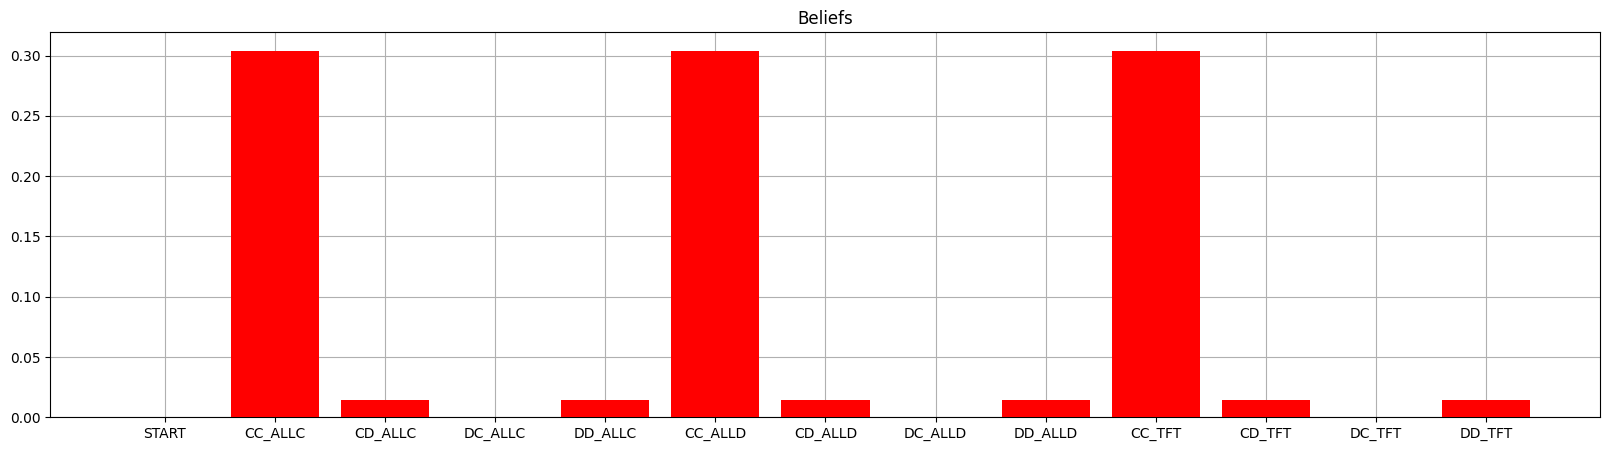

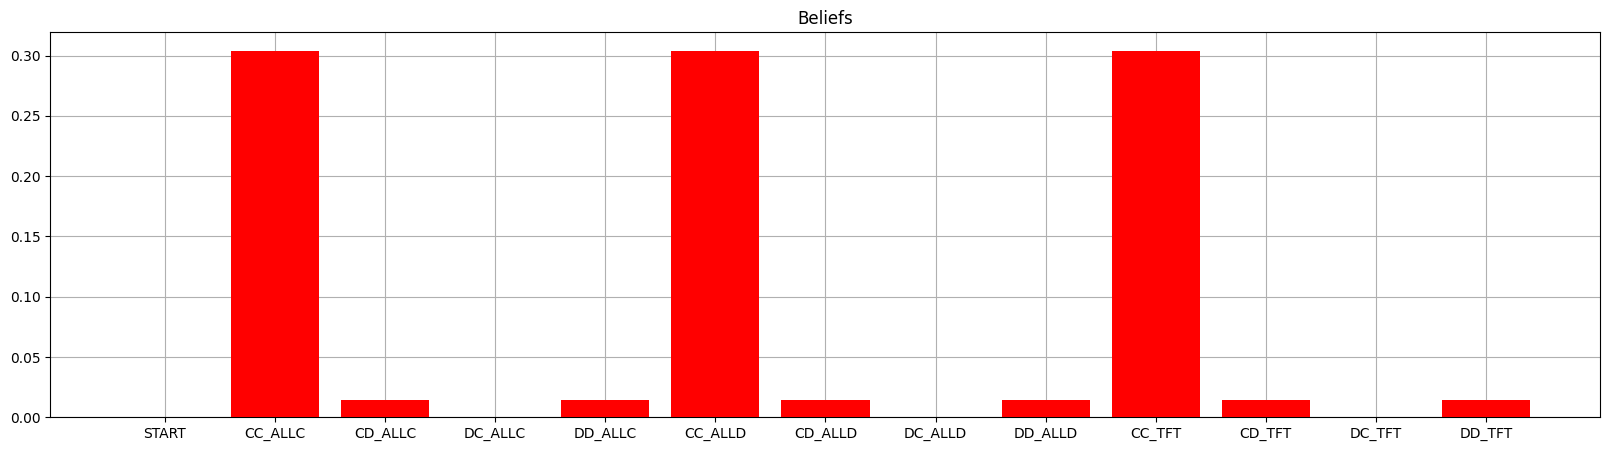

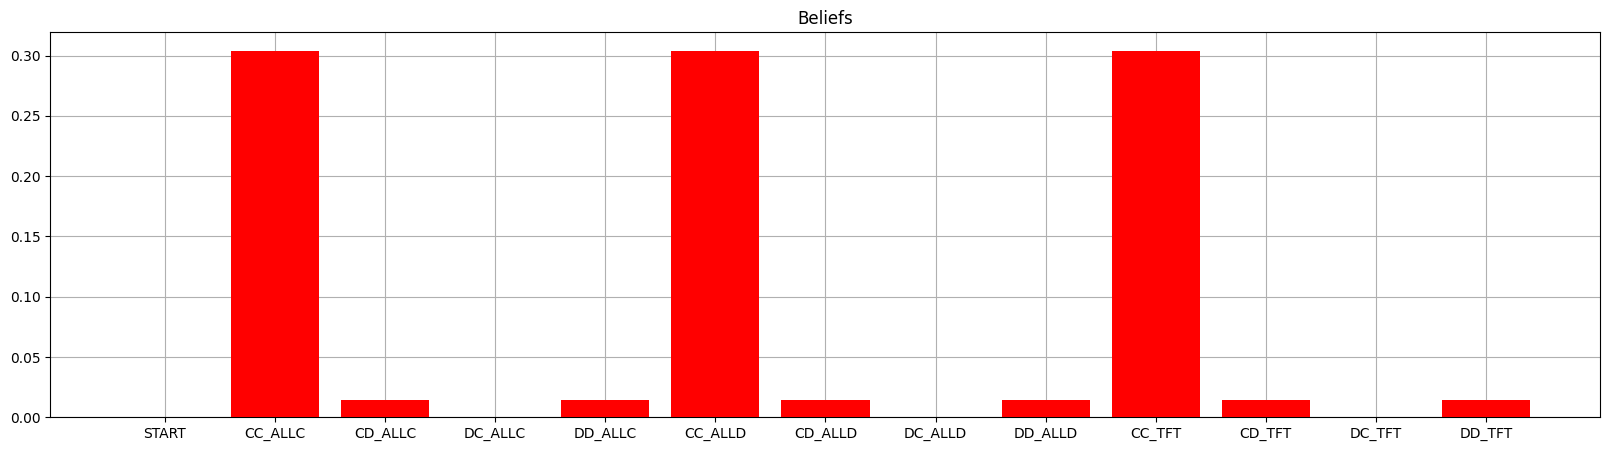

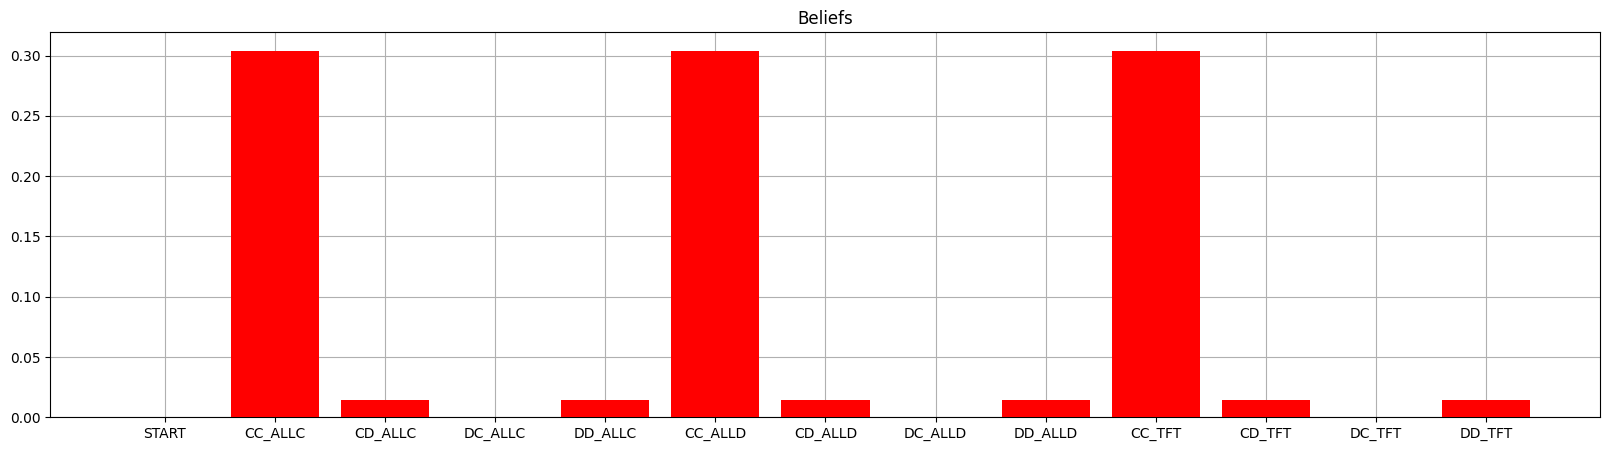

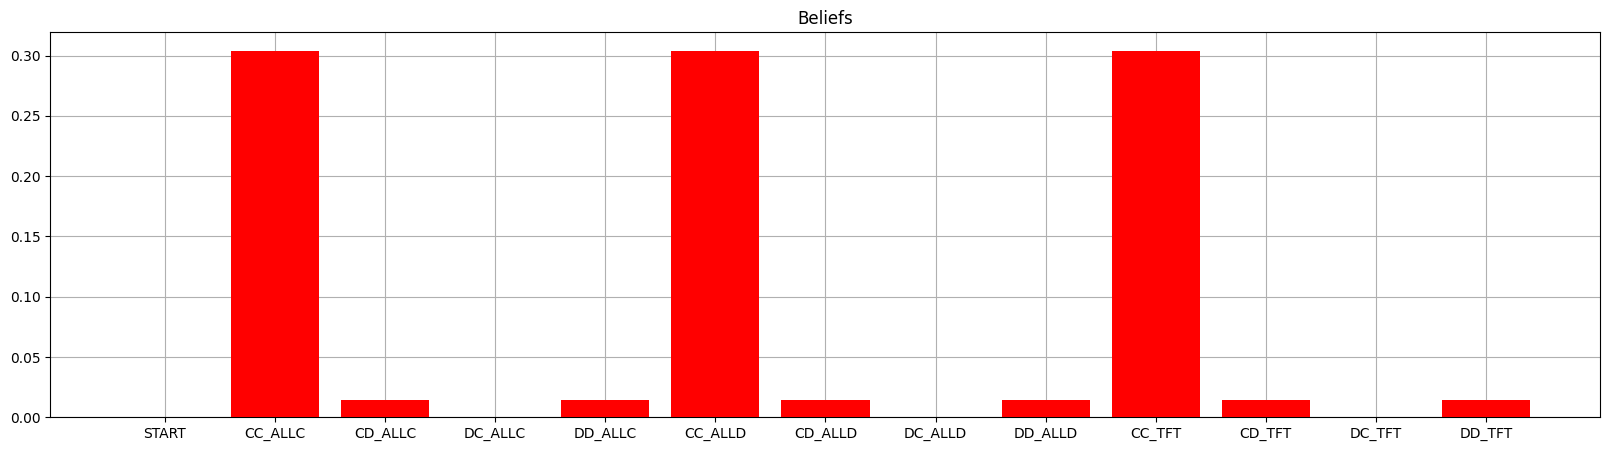

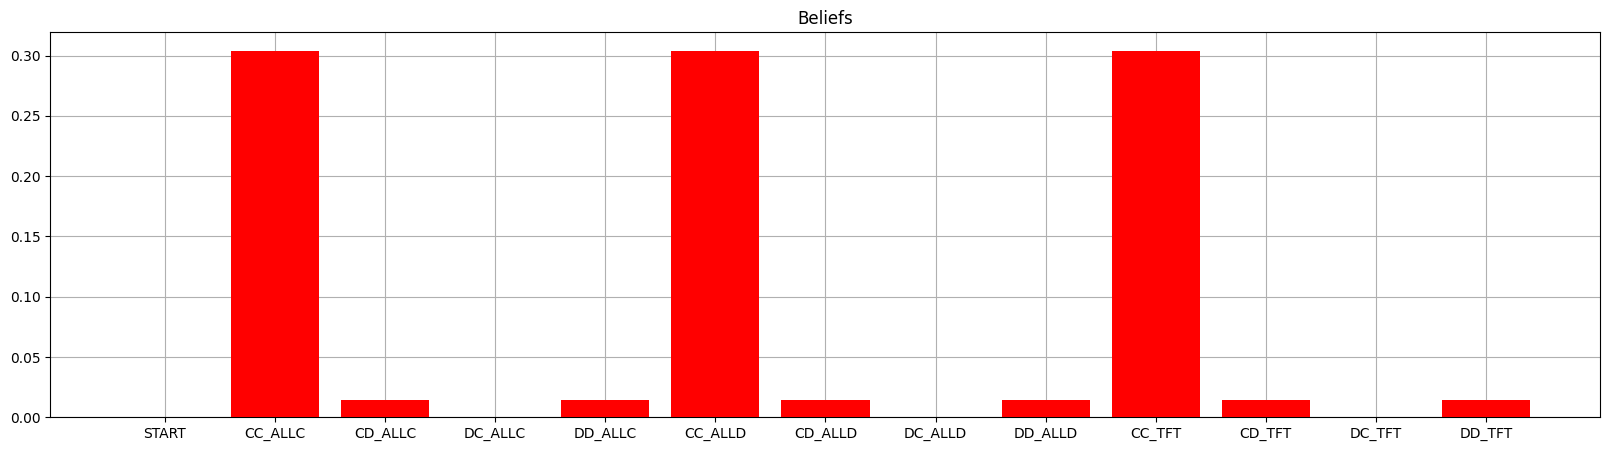

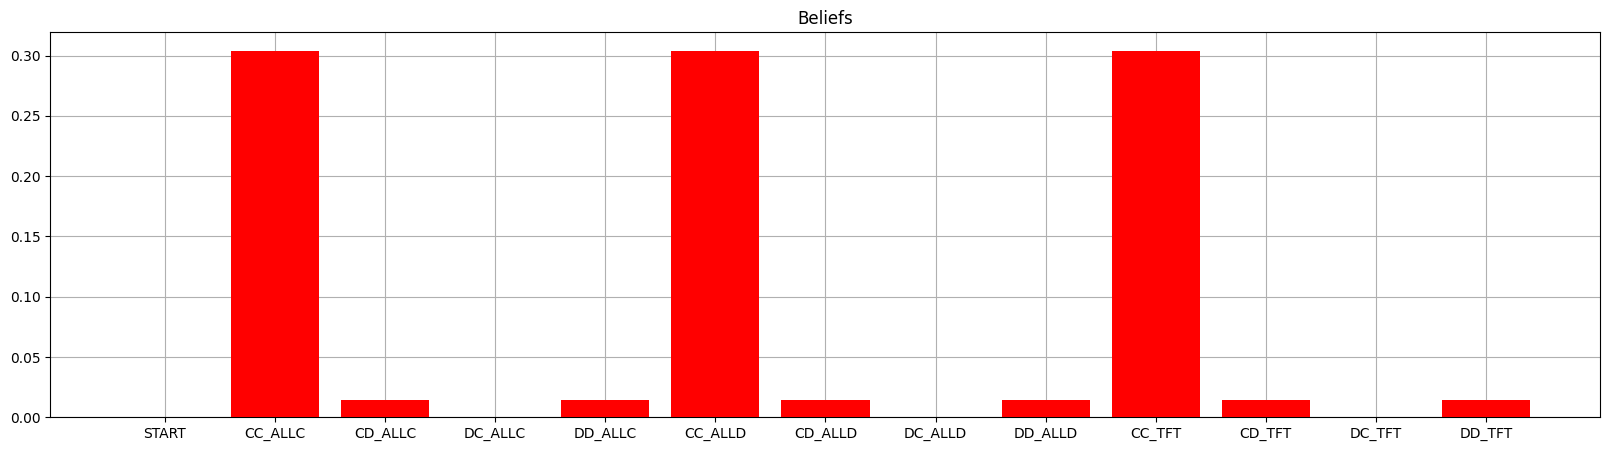

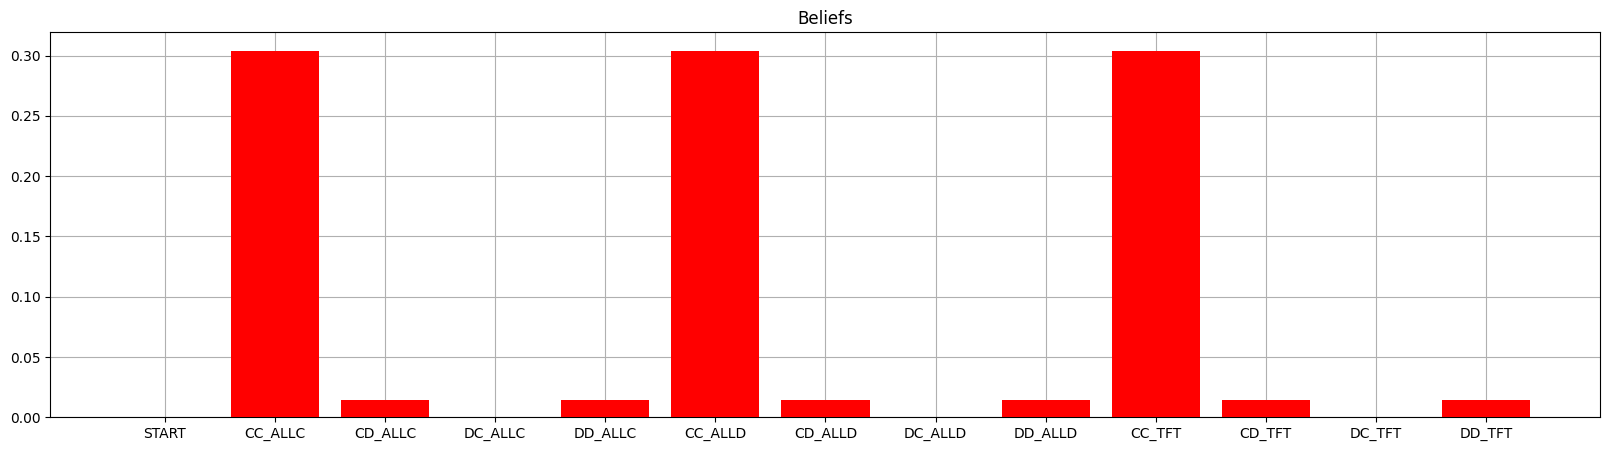

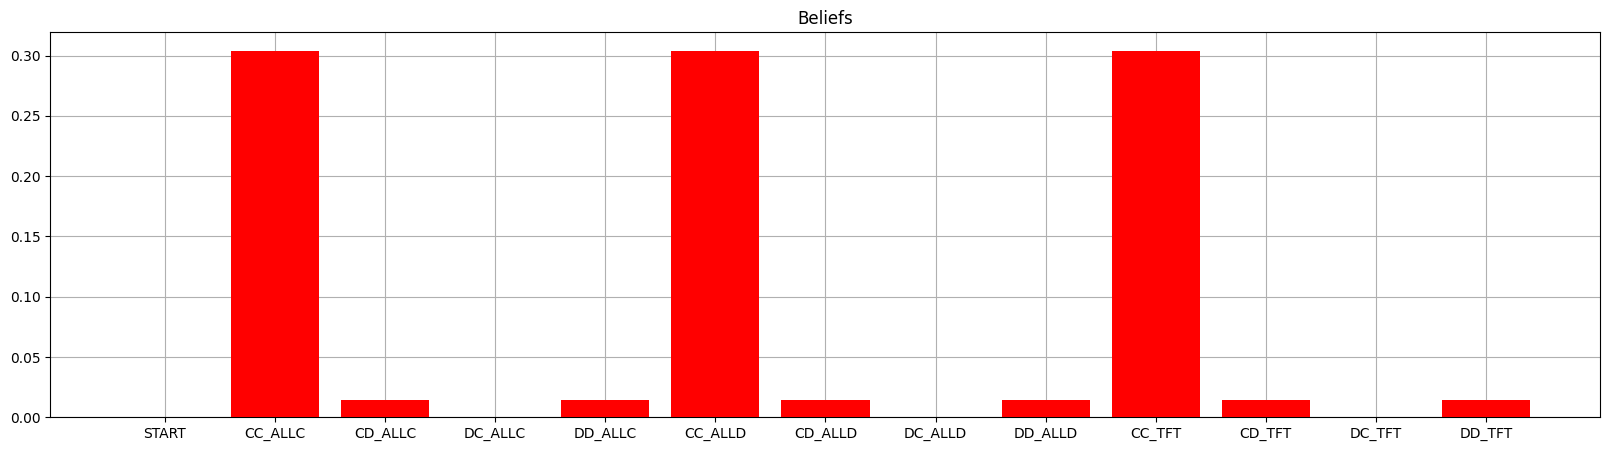

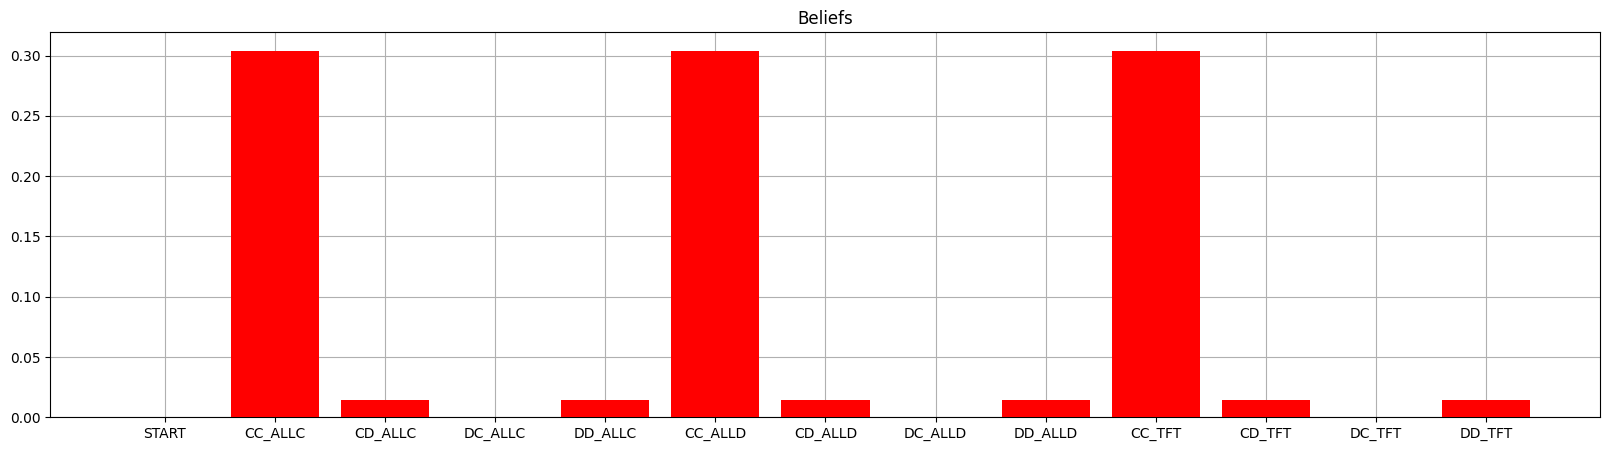

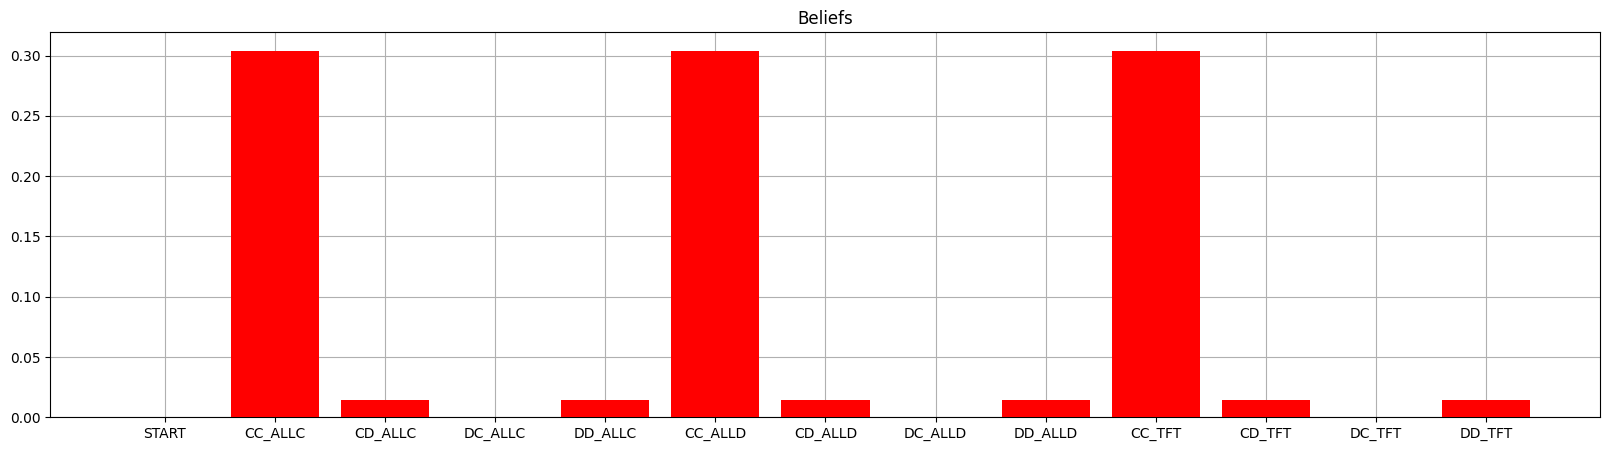

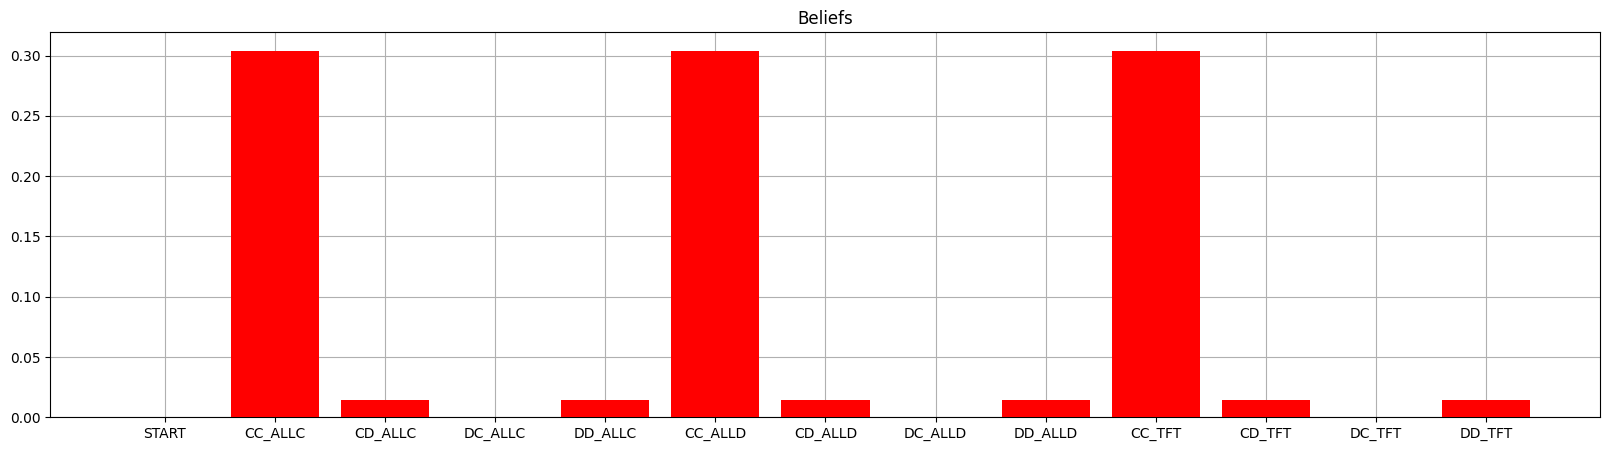

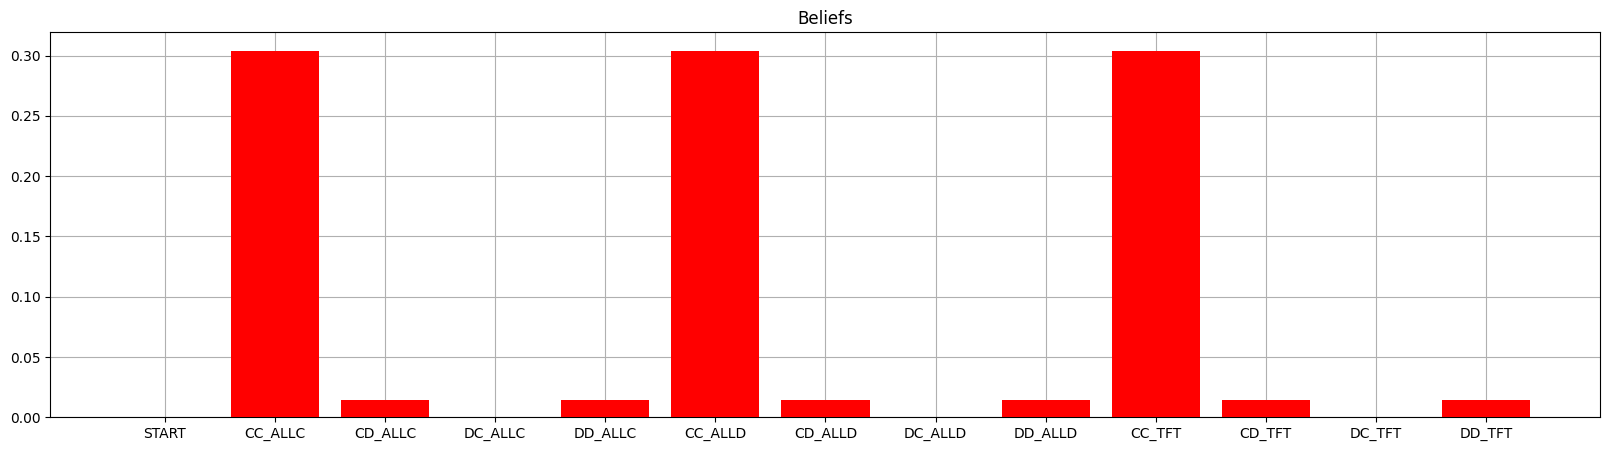

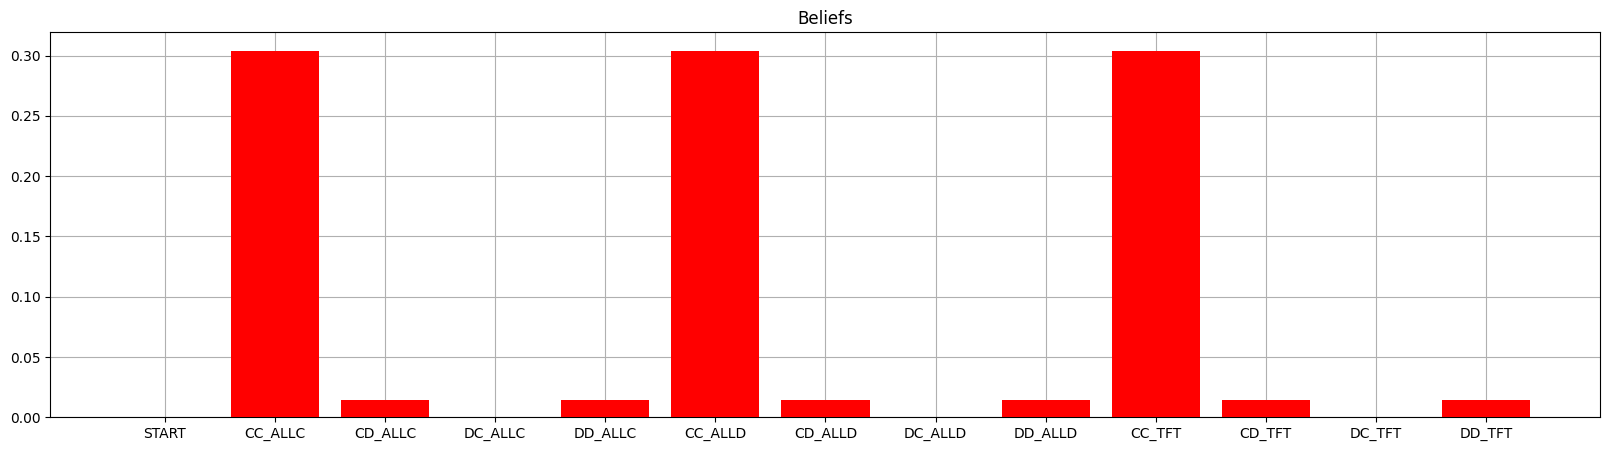

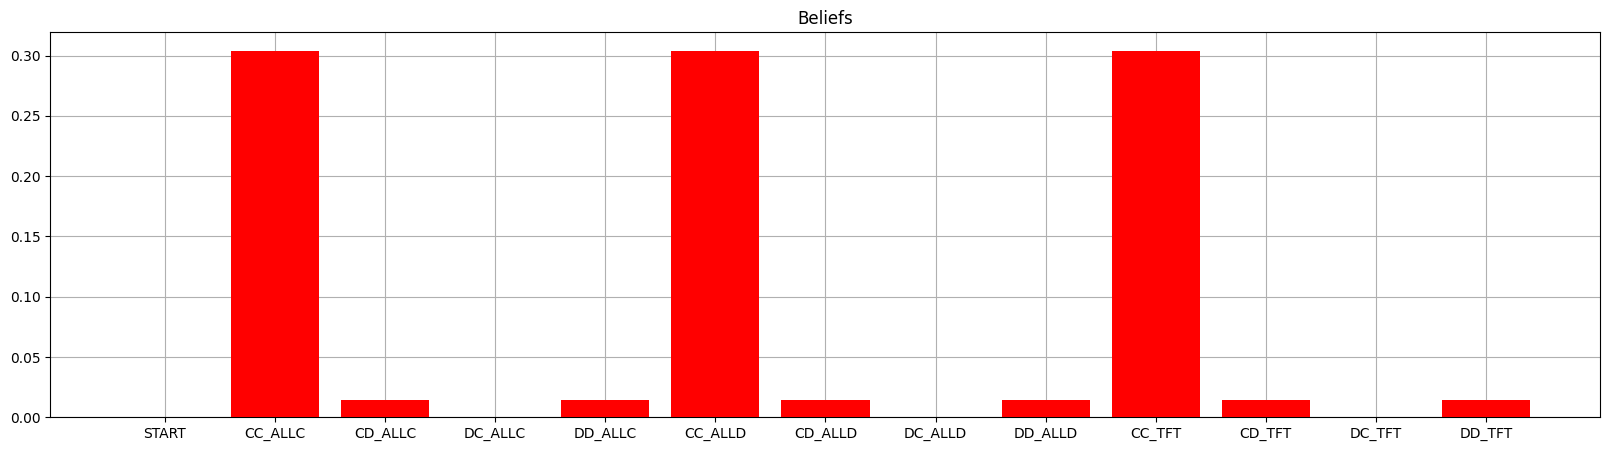

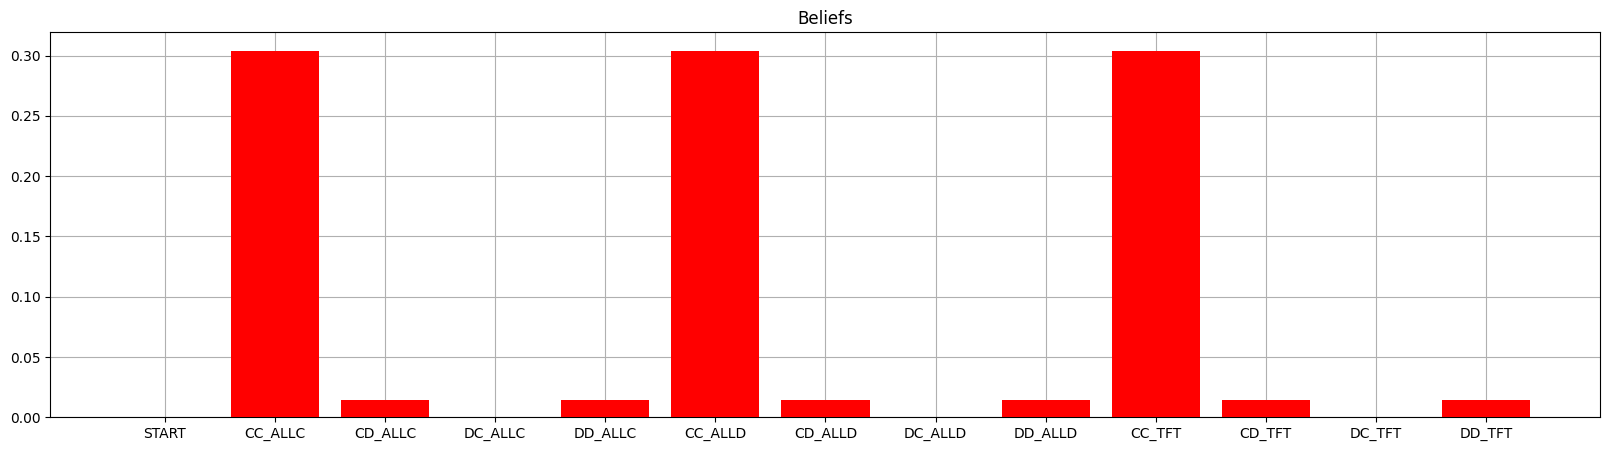

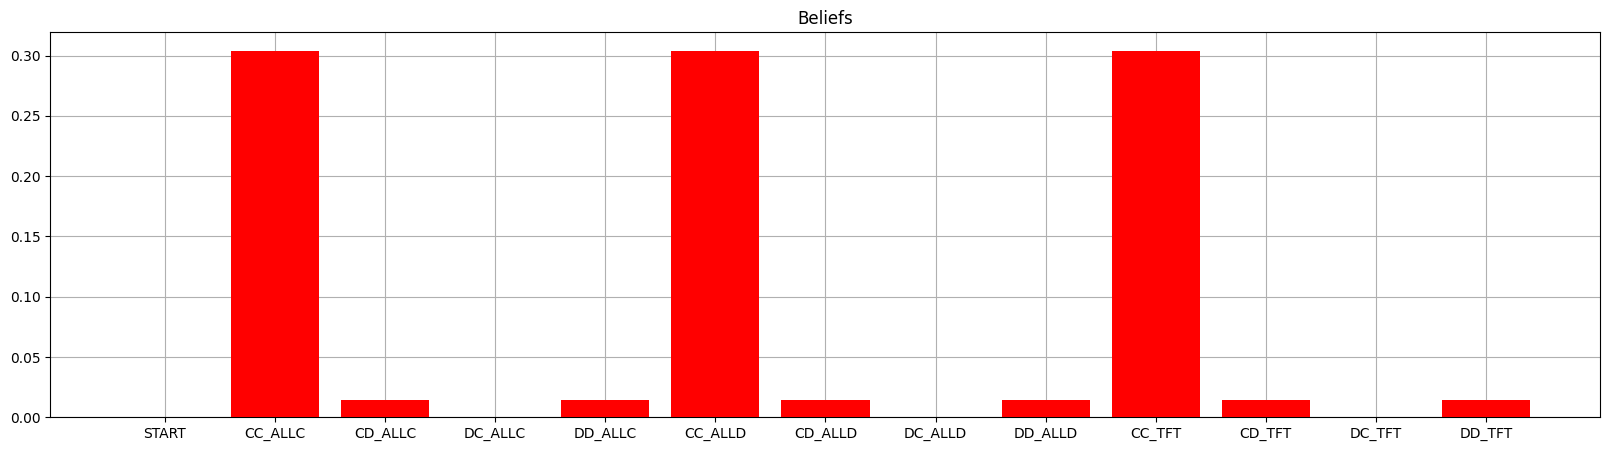

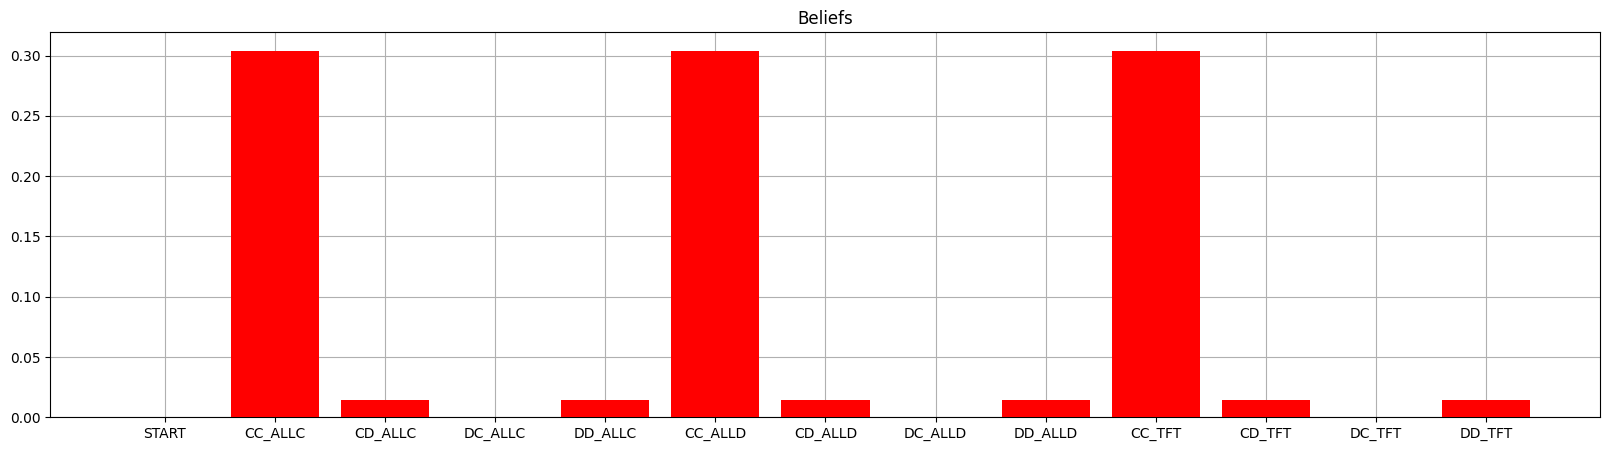

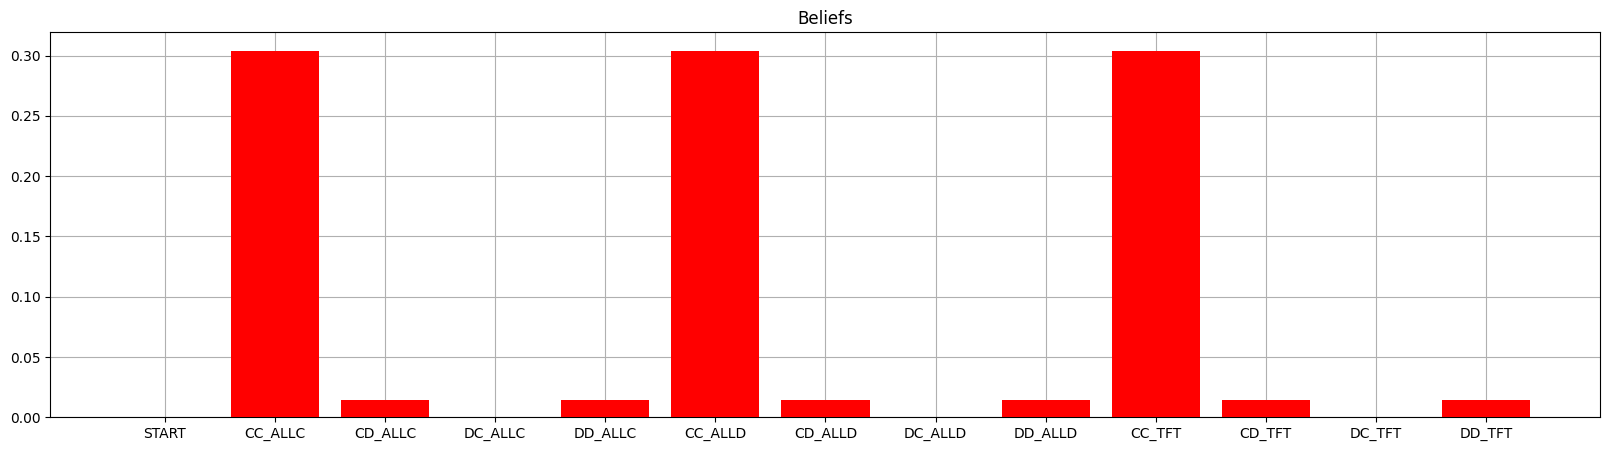

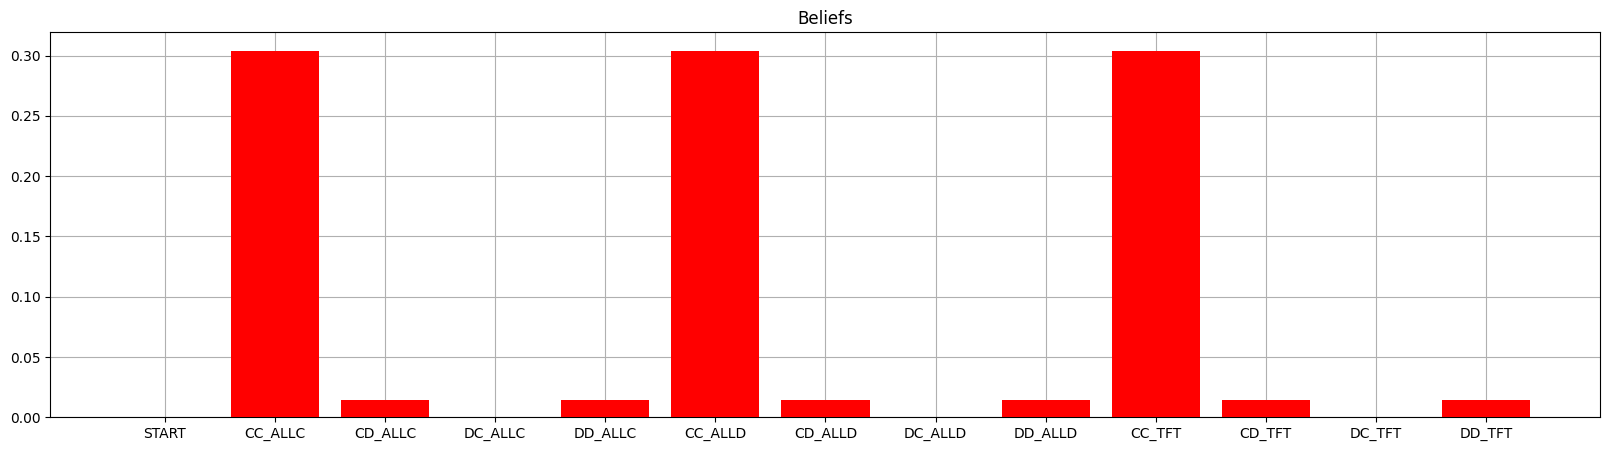

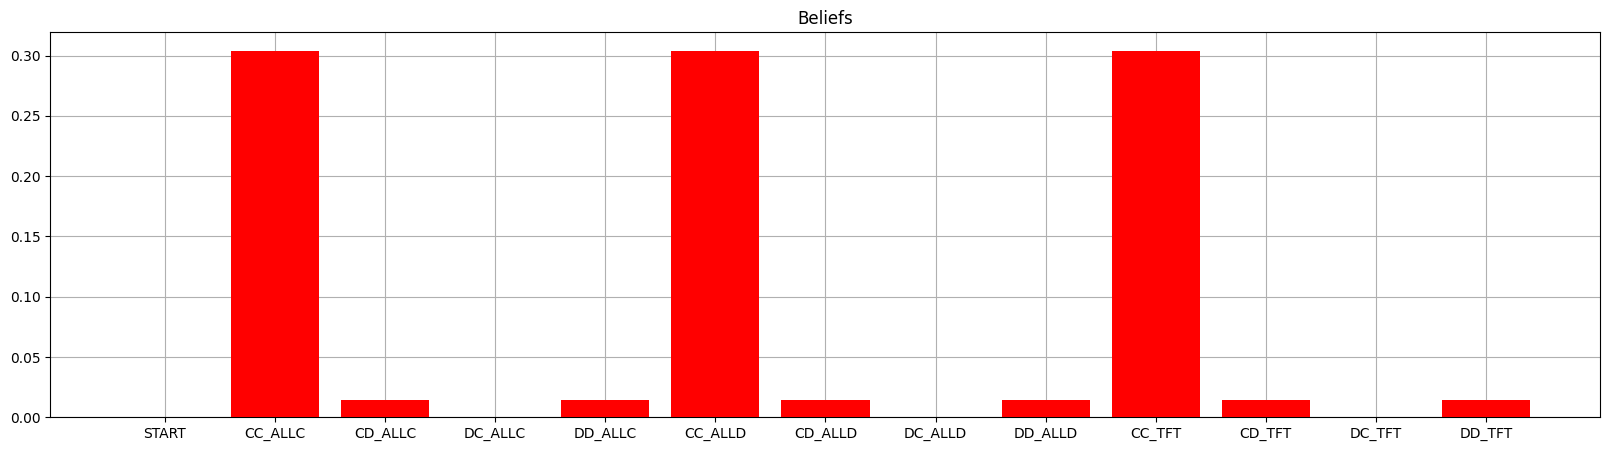

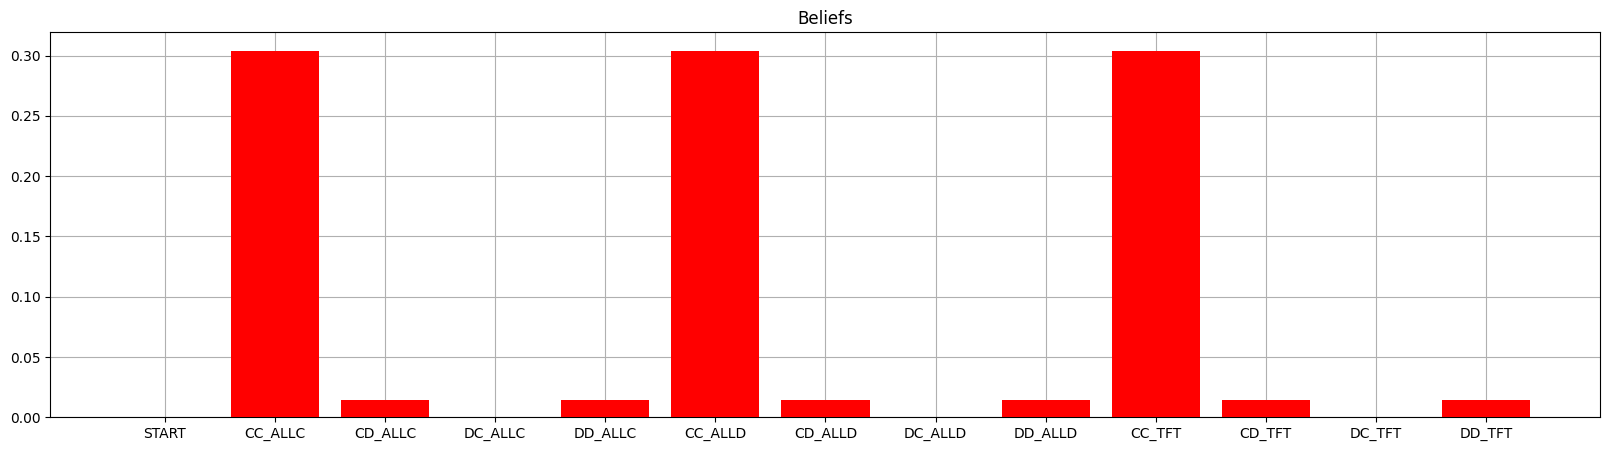

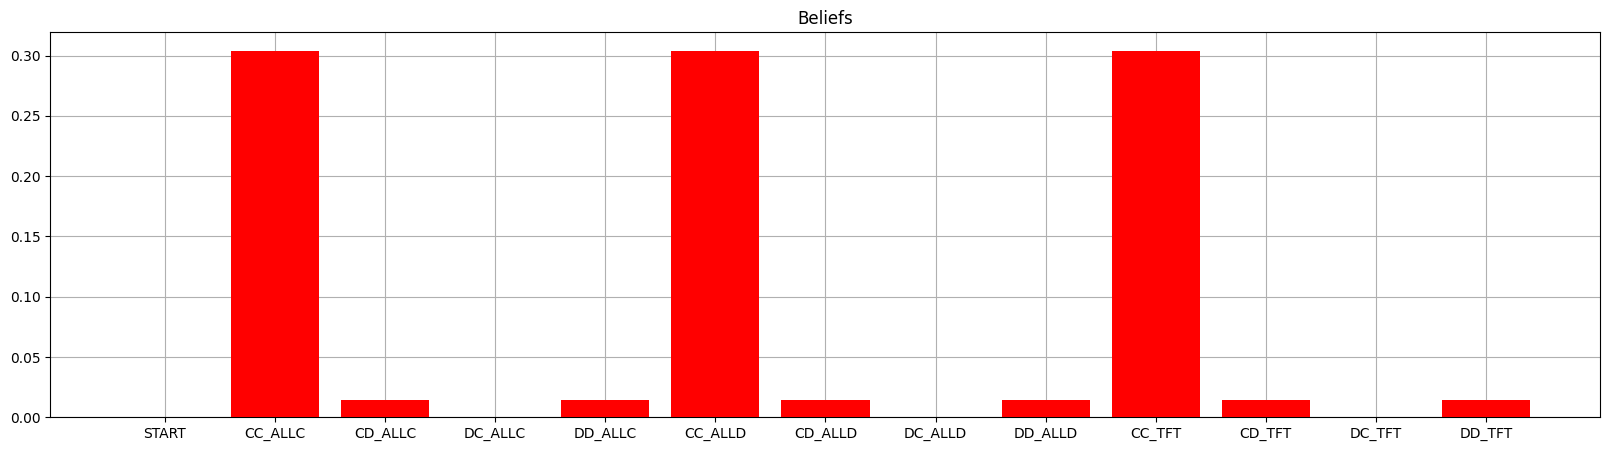

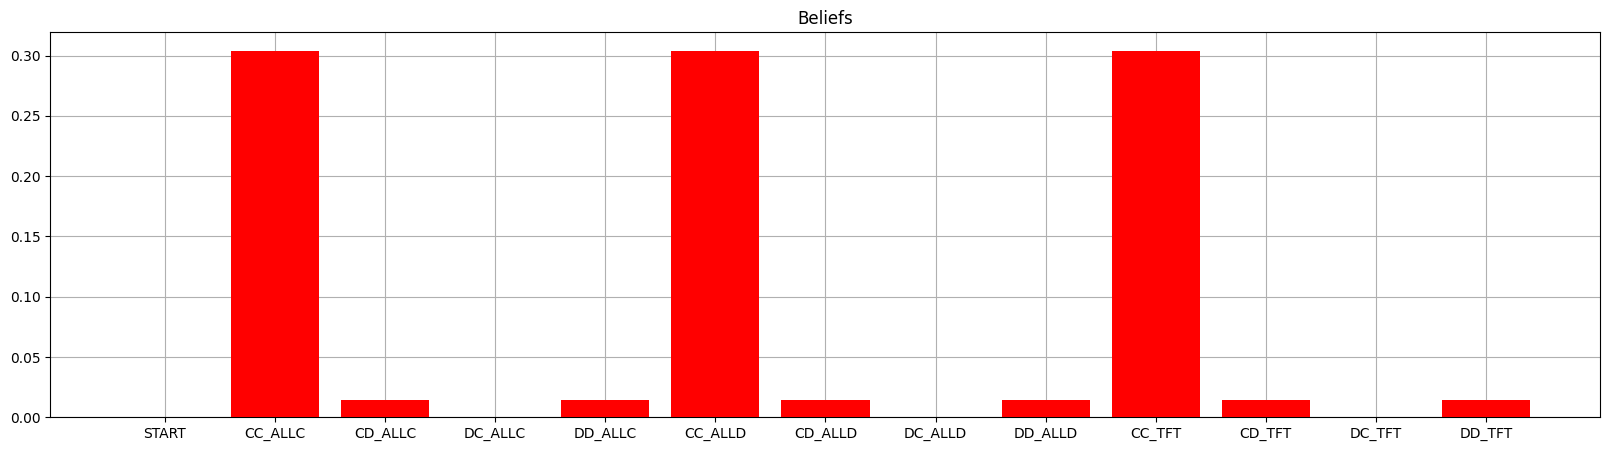

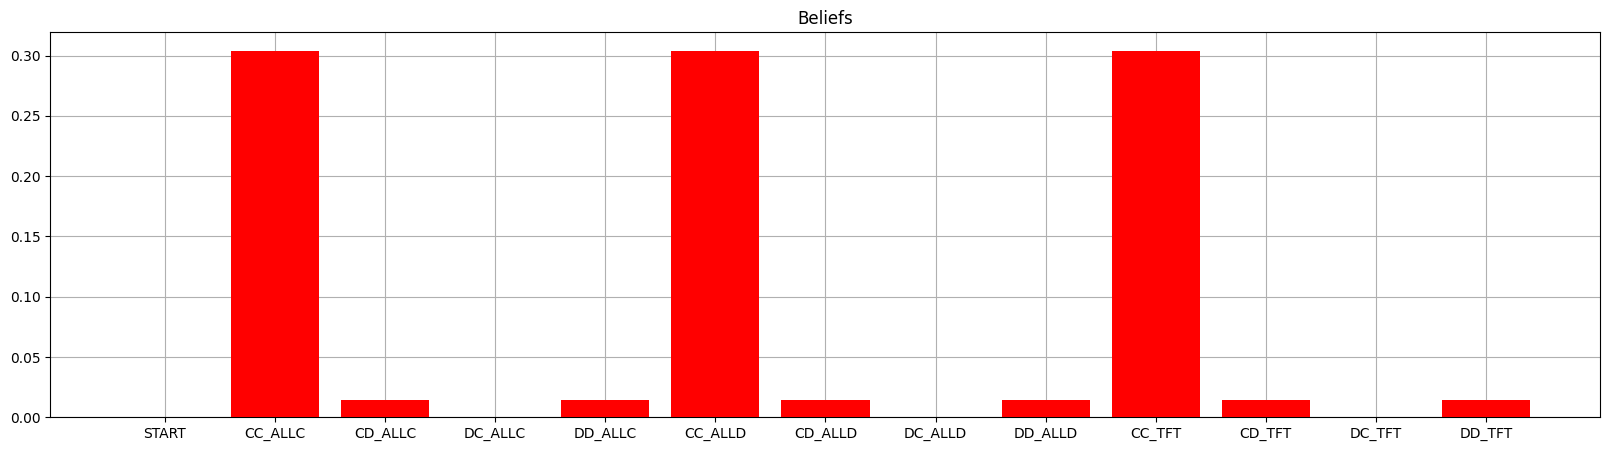

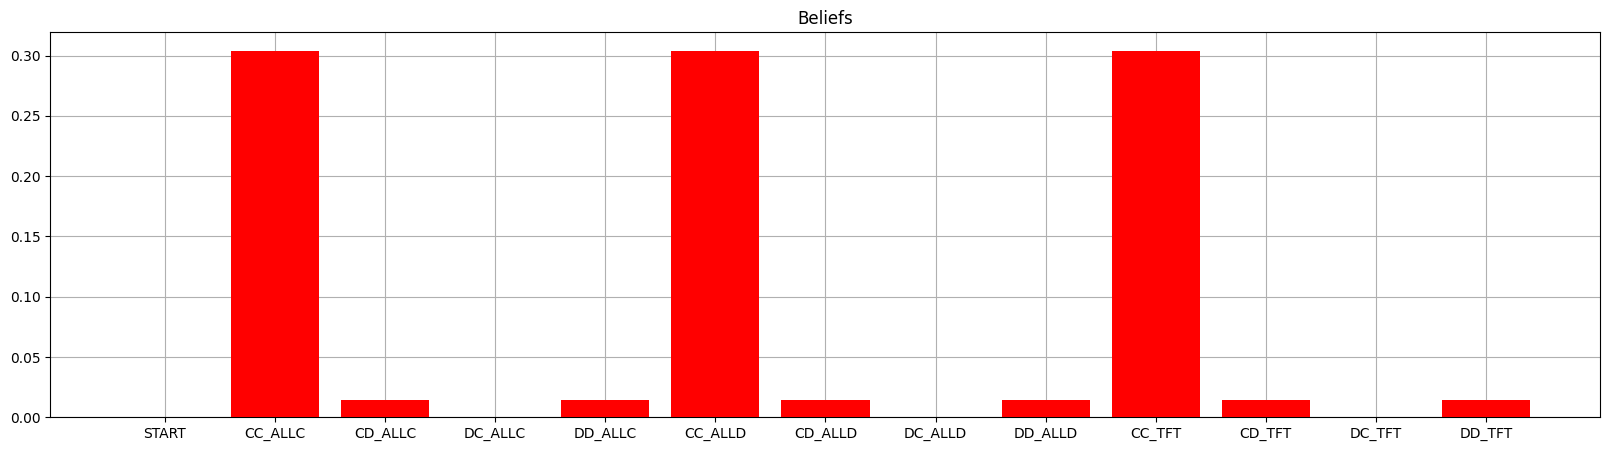

In [32]:


def run_new_agent(agent, num_timesteps):
    rng = jr.PRNGKey(0)
    strategy = jax.tree_util.Partial(alwaysdefect)
    last, infos = jit(rollout, static_argnums=[3,])(rng, agent, strategy, num_timesteps)
    for obs in infos['obs']:
        for o in obs:
            if o[0][0] == 1:
                print("CC")
            elif o[0][0] == 2:
                print("CD")
            elif o[0][0] == 3:
                print("DC")
            elif o[0][0] == 4:
                print("DD")
    for qs in infos['qs'][0].reshape(-1, num_states):
        plot_D_1(qs, "Beliefs")

                
run_new_agent(agent, 50)
